# AFL Data Foundations — EDA, Feature Engineering & Prediction Targets

## Task 1 — Data Inventory & Understanding

### Objective
The objective of this task is to load and inspect the complete AFL dataset, understand the structure and grain of each table, identify relationships between tables, and assess data quality before performing exploratory analysis or building prediction models.
The analysis will document:
- Dataset files and tables
- Row-level meaning and data grain
- Available columns and data types
- Join keys between tables
- Date and season coverage
- Teams and players covered
- Missing values
- Duplicate records
- Naming inconsistencies
- Outliers in important AFL statistics
- Structural changes across seasons

In [3]:
import os
from pathlib import Path

data_dir = Path(".")

files = []

for path in data_dir.rglob("*"):
    if path.is_file():
        files.append(path)

print("Files found:")
for file in files:
    print(file)

Files found:
AFL-Dataset.ipynb
afl_players_info_raw.csv
afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv
afl_players_seasonal_stats_raw.csv
team_matches_home_away_raw - team_matches_home_away_raw.csv.csv


In [5]:
# Load trhe Datasets
import pandas as pd

players_info = pd.read_csv("afl_players_info_raw.csv")

players_round = pd.read_csv(
    "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
)

players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")

team_matches = pd.read_csv(
    "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"
)


C:\Users\samir\AppData\Local\Temp\ipykernel_15480\3870726643.py:10: DtypeWarning: Columns (0: player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  players_seasonal = pd.read_csv("afl_players_seasonal_stats_raw.csv")


In [6]:
datasets = {
    "Players Info": players_info,
    "Players Round-by-Round": players_round,
    "Players Seasonal": players_seasonal,
    "Team Matches Home-Away": team_matches
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")

Players Info: 2848 rows × 16 columns
Players Round-by-Round: 274089 rows × 36 columns
Players Seasonal: 25491 rows × 54 columns
Team Matches Home-Away: 15808 rows × 19 columns


In [7]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print("Columns:")
    print(df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
Columns:
['id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'profile_pic', 'player_link', 'player_common_names', 'player_teams']

Data Types:
id                     int64
player_name              str
player_full_name         str
first_name               str
last_name                str
born_date                str
debut_date               str
debut_age              int64
last_date                str
last_age               int64
height                 int64
weight                 int64
profile_pic              str
player_link              str
player_common_names      str
player_teams             str
dtype: object

----------------------------------------------------------------------
Players Round-by-Round
--------------------------

In [9]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    display(df.head())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------


,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."



----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25



----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN



----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


In [10]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    
    print("Duplicate rows:", df.duplicated().sum())
    
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    print("\nMissing values:")
    print(missing if len(missing) > 0 else "No missing values")


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
Duplicate rows: 5

Missing values:
player_common_names    2773
profile_pic            2211
player_teams             94
dtype: int64

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
Duplicate rows: 10

Missing values:
score                        274089
brownlow_votes               110481
goal_assist                  103600
bounces                       97343
hit_outs                      96629
marks_inside_50               91378
contested_marks               90677
behinds                       81093
goals                         74737
percentage_of_game_played     69682
clearances                    63919
rebound_50s                   62856
one_percenters                60146
free_kicks_for                53842
free_k

In [11]:
print("PLAYERS INFO")
print("Rows:", len(players_info))
print("Unique players:", players_info.nunique().max())

print("\nROUND-BY-ROUND")
print("Rows:", len(players_round))

print("\nSEASONAL STATS")
print("Rows:", len(players_seasonal))

print("\nTEAM MATCHES")
print("Rows:", len(team_matches))

PLAYERS INFO
Rows: 2848
Unique players: 2843

ROUND-BY-ROUND
Rows: 274089

SEASONAL STATS
Rows: 25491

TEAM MATCHES
Rows: 15808


In [12]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    for col in df.columns:
        unique_count = df[col].nunique(dropna=True)
        print(f"{col}: {unique_count} unique values")


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
id: 2843 unique values
player_name: 2826 unique values
player_full_name: 2843 unique values
first_name: 742 unique values
last_name: 1998 unique values
born_date: 2546 unique values
debut_date: 1610 unique values
debut_age: 14 unique values
last_date: 1305 unique values
last_age: 22 unique values
height: 44 unique values
weight: 54 unique values
profile_pic: 636 unique values
player_link: 2843 unique values
player_common_names: 75 unique values
player_teams: 309 unique values

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
id: 274079 unique values
team: 20 unique values
year: 43 unique values
career_game_count: 432 unique values
opponent: 20 unique values
round: 30 unique values
result: 3 unique values
jersey_num: 60

In [13]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    
    numeric_cols = df.select_dtypes(include="number").columns
    
    if len(numeric_cols) > 0:
        display(df[numeric_cols].describe().T)
    else:
        print("No numeric columns found.")


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,2848.0,44858.623947,912.449281,43260.0,44063.75,44885.5,45662.25,46374.0
debut_age,2848.0,19.595857,1.824956,16.0,18.00,19.0,20.00,29.0
last_age,2848.0,25.765449,4.339853,18.0,22.00,25.0,29.00,40.0
height,2848.0,187.344803,7.318328,163.0,182.00,187.0,192.00,211.0
weight,2848.0,86.012289,8.923524,0.0,80.00,85.0,92.00,118.0



----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,274089.0,317627.891590,238902.057585,1.0,72923.0,397686.0,551104.0,619682.0
year,274089.0,2010.140524,9.443820,1983.0,2002.0,2011.0,2018.0,2025.0
career_game_count,274089.0,90.230786,72.632905,1.0,31.0,73.0,135.0,432.0
jersey_num,274089.0,20.045664,12.657641,1.0,9.0,19.0,30.0,67.0
kicks,272789.0,9.202508,4.709571,0.0,6.0,9.0,12.0,37.0
marks,266038.0,4.078474,2.550794,0.0,2.0,4.0,6.0,24.0
handballs,269656.0,6.368996,4.077075,0.0,3.0,6.0,9.0,35.0
disposals,265636.0,15.070299,7.304748,-5.0,10.0,14.0,20.0,54.0
goals,199352.0,0.825108,1.147711,0.0,0.0,0.0,1.0,16.0
behinds,192996.0,0.606044,0.854019,0.0,0.0,0.0,1.0,11.0



----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
year,25491.0,2010.194500,9.342562,1983.0,2003.0,2011.0,2018.00,2025.0
games_played,25491.0,10.748617,7.832753,-21.0,3.0,10.0,19.00,23.0
kicks,25439.0,98.697001,92.259369,0.0,20.0,66.0,161.00,512.0
marks,25306.0,42.882281,39.119496,0.0,9.0,31.0,70.00,226.0
handballs,25378.0,67.689652,68.603571,0.0,13.0,44.0,103.00,482.0
disposals,25467.0,166.041583,154.153533,0.0,34.0,114.0,268.00,787.0
goals,22954.0,7.169208,10.744221,0.0,1.0,3.0,9.00,123.0
behinds,22802.0,5.131524,6.806970,0.0,1.0,3.0,7.00,84.0
hit_outs,19785.0,21.316250,80.547687,0.0,0.0,0.0,4.00,1007.0
tackles,24980.0,26.029944,26.819368,0.0,6.0,17.0,38.00,205.0



----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,15808.0,7904.500000,4563.520863,1.0,3952.75,7904.5,11856.25,15808.0
year,15808.0,2005.303517,12.202924,1983.0,1995.00,2006.0,2016.00,2025.0
team_score,15808.0,92.323064,29.581855,13.0,71.00,90.0,110.00,239.0
opponent_score,15808.0,92.323064,29.581855,13.0,71.00,90.0,110.00,239.0
margin,15808.0,0.001835,44.771226,-186.0,-30.00,0.0,30.00,186.0
crowd,15410.0,32522.293446,17607.923243,1241.0,20031.00,29814.0,40844.00,110332.0
team_goals_kicked,15808.0,13.398406,4.717789,1.0,10.00,13.0,16.00,37.0
team_behinds,15808.0,11.932629,4.003741,1.0,9.00,12.0,14.00,31.0
opponent_goals_kicked,15808.0,13.398406,4.717789,1.0,10.00,13.0,16.00,37.0
opponent_behinds,15808.0,11.932629,4.003741,1.0,9.00,12.0,14.00,31.0


In [15]:
# Team  Player Naming/Comsistency
import re

def normalize_name(value):
    if pd.isna(value):
        return value
    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)
    return value

for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    for col in df.columns:
        if df[col].dtype == "object":
            values = df[col].dropna().astype(str)
            normalized = values.map(normalize_name)

            if values.nunique() != normalized.nunique():
                print(
                    f"Possible naming/spacing inconsistency: {col} "
                    f"({values.nunique()} original → {normalized.nunique()} normalized)"
                )


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------

----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------


In [16]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        series = df[col].dropna()

        if len(series) < 4:
            continue

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = series[(series < lower) | (series > upper)]

        if len(outliers) > 0:
            print(
                f"{col}: {len(outliers)} outliers "
                f"(range: {lower:.2f} to {upper:.2f})"
            )


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
debut_age: 134 outliers (range: 15.00 to 23.00)
last_age: 1 outliers (range: 11.50 to 39.50)
height: 10 outliers (range: 167.00 to 207.00)
weight: 10 outliers (range: 62.00 to 110.00)

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
career_game_count: 3126 outliers (range: -125.00 to 291.00)
jersey_num: 8 outliers (range: -22.50 to 61.50)
kicks: 3265 outliers (range: -3.00 to 21.00)
marks: 1409 outliers (range: -4.00 to 12.00)
handballs: 3144 outliers (range: -6.00 to 18.00)
disposals: 1658 outliers (range: -5.00 to 35.00)
goals: 16212 outliers (range: -1.50 to 2.50)
behinds: 7056 outliers (range: -1.50 to 2.50)
hit_outs: 26657 outliers (range: -1.50 to 2.50)
tackles: 4114 outliers (range: -3.50 to 8.50)
rebound_50s: 

In [17]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    for col in df.columns:
        col_lower = col.lower()

        if any(word in col_lower for word in ["date", "season", "year", "round"]):
            print(f"\nColumn: {col}")
            print("Sample values:")
            print(df[col].dropna().head(10).tolist())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------

Column: born_date
Sample values:
['1991-06-25', '1984-05-14', '2001-08-21', '1985-12-13', '1982-03-16', '1995-10-07', '1988-04-06', '1993-09-20', '1985-11-15', '1987-10-07']

Column: debut_date
Sample values:
['2018-08-02', '2002-03-30', '2022-07-30', '2005-08-12', '2001-03-30', '2014-05-02', '2007-04-29', '2012-04-28', '2004-05-08', '2006-08-18']

Column: last_date
Sample values:
['2020-09-05', '2020-10-24', '2025-09-06', '2011-08-28', '2008-05-16', '2025-08-20', '2014-08-30', '2025-06-06', '2016-07-29', '2014-05-31']

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------

Column: year
Sample values:
[1994, 2024, 1999, 1994, 1997, 2002, 2002, 2002, 1997, 1997]

Column: round
Sample values:
['21', '1', '10', '21', '10', '2

In [19]:
for name, df in datasets.items():
    season_cols = [c for c in df.columns if c.lower() in ["season", "year", "season_year"]]

    if season_cols:
        season_col = season_cols[0]

        print("\n" + "-" * 70)
        print(name)
        print("-" * 70)

        print("Seasons covered:")
        print(sorted(df[season_col].dropna().unique().tolist()))


----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
Seasons covered:
[1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------
Seasons covered:
[1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

----------------------------------------------------------------------
Team Matches Home-Away
---------------------------

In [21]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    for col in df.columns:
        col_lower = col.lower()

        if "team" in col_lower or "player" in col_lower:
            unique_values = df[col].dropna().nunique()

            print(f"{col}: {unique_values} unique values")


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
player_name: 2826 unique values
player_full_name: 2843 unique values
player_link: 2843 unique values
player_common_names: 75 unique values
player_teams: 309 unique values

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
team: 20 unique values
player_id: 3109 unique values

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------
player_id: 3298 unique values
team: 114 unique values

----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------
team_name: 40 unique values
team_quarter_scores: 15750 unique values
team_

In [22]:
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    for col in df.columns:
        if "date" in col.lower():
            dates = pd.to_datetime(df[col], errors="coerce")

            print(f"{col}:")
            print("Earliest:", dates.min())
            print("Latest:", dates.max())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
born_date:
Earliest: 1963-10-23 00:00:00
Latest: 2006-12-24 00:00:00
debut_date:
Earliest: 1983-03-27 00:00:00
Latest: 2025-08-22 00:00:00
last_date:
Earliest: 1999-03-27 00:00:00
Latest: 2026-03-07 00:00:00

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
match_date:
Earliest: 1983-03-27 00:00:00
Latest: 2025-09-27 00:00:00

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------

----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------
match_date:
Earliest: 1983-03-26 00:00:00
Latest: 2025-09-27 00:00:00


In [23]:
# Final Checks
for name, df in datasets.items():
    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing cells:", df.isna().sum().sum())


----------------------------------------------------------------------
Players Info
----------------------------------------------------------------------
Rows: 2848
Columns: 16
Duplicate rows: 5
Missing cells: 5078

----------------------------------------------------------------------
Players Round-by-Round
----------------------------------------------------------------------
Rows: 274089
Columns: 36
Duplicate rows: 10
Missing cells: 1608029

----------------------------------------------------------------------
Players Seasonal
----------------------------------------------------------------------
Rows: 25491
Columns: 54
Duplicate rows: 10
Missing cells: 139253

----------------------------------------------------------------------
Team Matches Home-Away
----------------------------------------------------------------------
Rows: 15808
Columns: 19
Duplicate rows: 0
Missing cells: 398


## Task 1 — Data Inventory & Understanding — Findings

### Dataset Inventory
The AFL dataset consists of four raw tables:

| Dataset | Description | Expected Grain |
|---|---|---|
| afl_players_info_raw.csv | Player biographical and profile information | One row per player |
| afl_players_round_by_round_stats_raw.csv | Player performance statistics for individual rounds/matches | One row per player per match/round |
| afl_players_seasonal_stats_raw.csv | Aggregated player statistics for a season | One row per player per season |
| team_matches_home_away_raw.cs | Team-level match results and home/away information | One row per team-match |

### Relationships and Join Structure
The player-related tables can be connected using player identifiers or consistent player names where available. The round-by-round player statistics provide match-level player performance, while the seasonal table provides season-level aggregation.

The team match table provides the match-level team outcome information required for prediction. Match, team, player, season, and round identifiers are used as join keys where available.
### Data Quality
Missing-value counts and duplicate rows were checked for every dataset. Potential naming inconsistencies were also tested by normalizing text values for whitespace and capitalization.

No obvious naming or spacing inconsistencies were detected by the normalization check.

### Outlier Analysis
An IQR-based statistical outlier check was performed on numeric variables. Several variables contain statistical outliers, particularly player performance statistics such as goals, hit-outs, disposals, tackles, fantasy points, and team match statistics.

These observations are not automatically treated as errors because unusually high AFL performances can be legitimate. Therefore, the outlier check is used for investigation rather than automatic removal.
### Structural Changes
Season and date coverage were inspected to identify changes in the dataset over time. Team and player coverage was also examined across the available seasons.

Any historical team relocation, renaming, or rule-related changes should only be treated as confirmed when supported by the dataset or an external authoritative source.
### Task 1 Conclusion
The four raw AFL tables provide complementary information about players, player performance, seasonal performance, and team match outcomes. The datasets are suitable as the foundation for the next stages of the project, but joins and feature construction must respect match dates and season chronology to prevent data leakage.

# Task 2 — Define Prediction Targets Precisely

## Match Winner Target

The primary match-level prediction target is the match outcome.

For each match, the target is defined using the final home-team and away-team scores:

- home_win = 1 when the home team scores more points than the away team.
- away_win = 0 when the away team scores more points than the home team.
- draw = a separate class when both teams have the same score.

The target is therefore a three-class classification problem:

home_win, away_win, and draw.

### Why Classification?
Classification is selected because the main objective is to predict which team wins a match. It provides a direct and interpretable prediction target for the match-winner use case.

The final match margin can also be retained as an additional regression target:
margin = home_score - away_score
However, margin is not used as the primary target because the main business question is match outcome rather than the exact winning margin.

In [24]:
# Actual Match Wining Target 
team_matches["match_result"] = team_matches.apply(
    lambda row: "home_win"
    if row["team_score"] > row["opponent_score"]
    else "away_win"
    if row["team_score"] < row["opponent_score"]
    else "draw",
    axis=1
)

print(team_matches["match_result"].value_counts())

match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64


In [25]:
result_counts = team_matches["match_result"].value_counts()

print("Match Outcome Distribution:")
print(result_counts)

print("\nMatch Outcome Percentage:")
print((result_counts / len(team_matches) * 100).round(2))

Match Outcome Distribution:
match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64

Match Outcome Percentage:
match_result
away_win    49.59
home_win    49.59
draw         0.82
Name: count, dtype: float64


##  Top Player Target — Disposal Leader

The first player-level target is the top disposal-getter.

For each match, the top disposal-getter is defined as the player who records the highest number of disposals in that match.

Formula:

top_disposals = argmax(player_disposals)

Aggregation level:

one player-match observation

This target represents the player who had the highest combined number of kicks and handballs/disposals in a match.

## Top Player Target — Goal Kicker

The second player-level target is the top goal-kicker.

For each match, the top goal-kicker is defined as the player who scores the highest number of goals in that match.

Formula:

`top_goals = argmax(player_goals)`

Aggregation level:

`one player-match observation`

This target identifies the player with the greatest goal-scoring output in a match.

##  Prediction Target Data Dictionary

| Target Name | Definition | Formula | Aggregation Level |
|---|---|---|---|
| `match_result` | Final match outcome | Compare home/team score with opponent score | Match |
| `match_margin` | Difference between team and opponent score | `team_score - opponent_score` | Match |
| `top_disposals` | Player with the highest disposals in a match | `argmax(disposals)` | Player-Match |
| `top_goals` | Player with the highest goals in a match | `argmax(goals)` | Player-Match |

These target definitions form the target contract for the Day 2 modelling stage. All target values must be calculated from final match results and player statistics while ensuring that future information is not included in predictive features.

In [28]:
player_stats = players_round.copy()

match_group = ["match_date", "round", "team", "opponent"]

player_stats["top_disposals"] = (
    player_stats["disposals"]
    == player_stats.groupby(match_group)["disposals"].transform("max")
).astype(int)

player_stats["top_goals"] = (
    player_stats["goals"]
    == player_stats.groupby(match_group)["goals"].transform("max")
).astype(int)

print("Top disposal records:", player_stats["top_disposals"].sum())
print("Top goal records:", player_stats["top_goals"].sum())

Top disposal records: 16299
Top goal records: 22270


In [29]:
top_disposal_players = player_stats[
    player_stats["top_disposals"] == 1
][
    ["player_id", "team", "opponent", "match_date", "round", "disposals"]
].sort_values("disposals", ascending=False)

top_goal_players = player_stats[
    player_stats["top_goals"] == 1
][
    ["player_id", "team", "opponent", "match_date", "round", "goals"]
].sort_values("goals", ascending=False)

print("Top Disposal Performances:")
display(top_disposal_players.head(10))

print("Top Goal Performances:")
display(top_goal_players.head(10))

Top Disposal Performances:


,player_id,team,opponent,match_date,round,disposals
167386,44910,North Melbourne Kangaroos,Richmond Tigers,2025-08-17,23,54.0
213046,44510,Hawthorn Hawks,Collingwood Magpies,2018-03-24,1,54.0
269304,43262,Gold Coast Suns,Collingwood Magpies,2012-06-03,10,53.0
165386,44585,Brisbane Lions,Richmond Tigers,2019-08-25,23,51.0
270187,45089,Adelaide Crows,Gold Coast Suns,2011-08-20,22,51.0
245586,44510,Hawthorn Hawks,Collingwood Magpies,2017-05-20,9,50.0
181913,43669,Western Bulldogs,Essendon Bombers,2025-05-17,10,49.0
93542,43262,Gold Coast Suns,Collingwood Magpies,2013-07-20,17,49.0
93097,45048,Collingwood Magpies,Hawthorn Hawks,2012-07-21,17,49.0
46159,44809,Brisbane Lions,Carlton Blues,2016-06-04,11,48.0


Top Goal Performances:


,player_id,team,opponent,match_date,round,goals
109698,45679,Sydney Swans,Fitzroy Lions,1995-08-13,19,16.0
58117,45679,St Kilda Saints,Sydney Swans,1992-06-13,13,15.0
183270,45460,West Coast Eagles,Adelaide Crows,2000-04-01,4,14.0
66540,45684,North Melbourne Kangaroos,Melbourne Demons,1990-07-07,14,14.0
226743,45752,Adelaide Crows,Carlton Blues,1994-03-27,1,13.0
170671,45677,Essendon Bombers,Sydney Swans,1999-04-10,3,13.0
84960,45752,Adelaide Crows,Richmond Tigers,1993-07-16,16,13.0
207738,45679,St Kilda Saints,Carlton Blues,1991-08-10,21,13.0
129212,43847,Hawthorn Hawks,North Melbourne Kangaroos,2012-06-02,10,13.0
239100,45679,St Kilda Saints,Sydney Swans,1991-05-19,9,12.0


In [30]:
print("Match Winner Target")
print(team_matches["match_result"].value_counts())

print("\nTop Disposal Getter")
print(player_stats["top_disposals"].value_counts())

print("\nTop Goal Kicker")
print(player_stats["top_goals"].value_counts())

Match Winner Target
match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64

Top Disposal Getter
top_disposals
0    257790
1     16299
Name: count, dtype: int64

Top Goal Kicker
top_goals
0    251819
1     22270
Name: count, dtype: int64


# Task 2 — Target Definition and Match-Level Labels

In this task, the prediction targets were defined from the AFL match and player-level data.

Two main match-level targets were created:

1. **Match Result**
   - `home_win` — the home team scored more points.
   - `away_win` — the away team scored more points.
   - `draw` — both teams scored the same number of points.

2. **Top Player Performance**
   - `top_disposals` identifies the player with the highest number of disposals in each match.
   - `top_goals` identifies the player with the highest number of goals in each match.

Since the dataset does not contain a unique `match_id`, matches were grouped using:

- `match_date`
- `round`
- `team`
- `opponent`



# Task 3 — Exploratory Data Analysis (EDA)

The objective of this task is to explore the AFL dataset and identify important patterns, trends, relationships, and differences between teams and players.

The analysis will focus on:

- Team win rates
- Match outcome distribution
- Home-ground advantage
- Season-wise performance trends
- Player performance distributions
- Historical top players and leaders
- Player and team consistency
- Differences between player positions, where available
- Relationships that may be useful for future match prediction

Visualizations will be used throughout the analysis to make important patterns easier to interpret.

In [31]:
print("Team-level dataset shape:", team_matches.shape)
print("Player-level dataset shape:", player_stats.shape)

print("\nTeam-level columns:")
print(team_matches.columns.tolist())

print("\nPlayer-level columns:")
print(player_stats.columns.tolist())

Team-level dataset shape: (15808, 20)
Player-level dataset shape: (274089, 38)

Team-level columns:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_result']

Player-level columns:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin', 'top_disposals', 'top_goals']


In [40]:
# Team Win Rates

team_eda = team_matches.copy()

# Remove hidden control characters from team labels.
team_eda["team_name_clean"] = (
    team_eda["team_name"].astype("string")
    .str.replace(r"[\x00-\x1f\x7f]", "", regex=True)
    .str.strip()
)

# Identify wins
team_eda["win"] = (
    team_eda["team_score"] > team_eda["opponent_score"]
).astype(int)

# Calculate team performance
team_win_rates = (
    team_eda.groupby("team_name_clean")["win"]
    .agg(["count", "sum", "mean"])
    .sort_values("mean", ascending=False)
)

# Rename columns
team_win_rates = team_win_rates.rename(columns={
    "count": "matches",
    "sum": "wins",
    "mean": "win_rate"
})

# Convert win rate to percentage
team_win_rates["win_rate_percent"] = (
    team_win_rates["win_rate"] * 100
).round(2)

display(team_win_rates)

,matches,wins,win_rate,win_rate_percent
team_name_clean,,,,
Geelong Cats,1013,619,0.611056,61.11
Hawthorn Hawks,1007,587,0.582920,58.29
Collingwood Magpies,996,540,0.542169,54.22
Port Adelaide Power,668,357,0.534431,53.44
Essendon Bombers,989,524,0.529828,52.98
West Coast Eagles,909,475,0.522552,52.26
Sydney Swans,998,521,0.522044,52.20
Adelaide Crows,803,415,0.516812,51.68
Brisbane Lions,677,345,0.509601,50.96


In [35]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 399.6 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.3 MB 399.6 kB/s eta 0:00:23
   -- ------------------------------------- 0.5/9.3 MB 399.6 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/9.3 MB 404.2 kB/s eta 0:00:22
   ---- ----------------------------------- 1.0/9.3 MB 465.9 kB/s eta 0:00:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


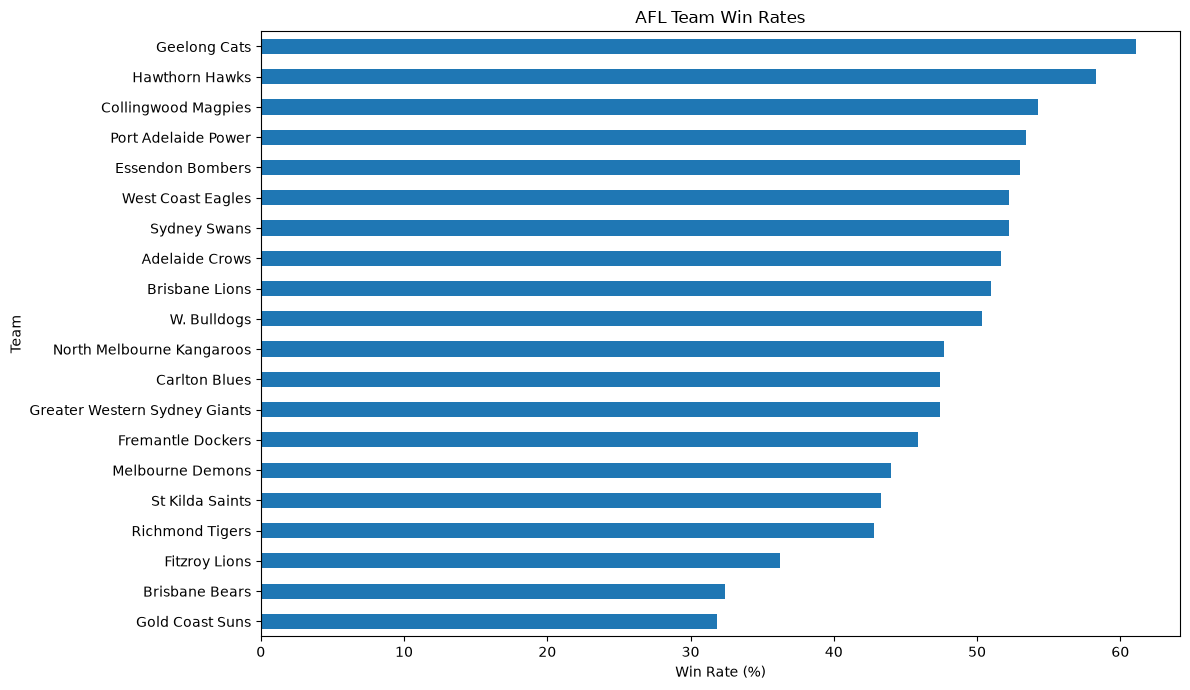

In [42]:
# Team Win Rate Visualization

plt.figure(figsize=(12, 7))

team_win_rates["win_rate_percent"].sort_values().plot(
    kind="barh"
)

plt.title("AFL Team Win Rates")
plt.xlabel("Win Rate (%)")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

In [43]:
#  Match Outcome Distribution

match_outcomes = team_matches["match_result"].value_counts()

print("Match Outcome Counts:")
print(match_outcomes)

Match Outcome Counts:
match_result
away_win    7839
home_win    7839
draw         130
Name: count, dtype: int64


In [44]:
# Match outcome percentages

match_outcome_percent = (
    team_matches["match_result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Match Outcome Percentages:")
print(match_outcome_percent)

Match Outcome Percentages:
match_result
away_win    49.59
home_win    49.59
draw         0.82
Name: proportion, dtype: float64


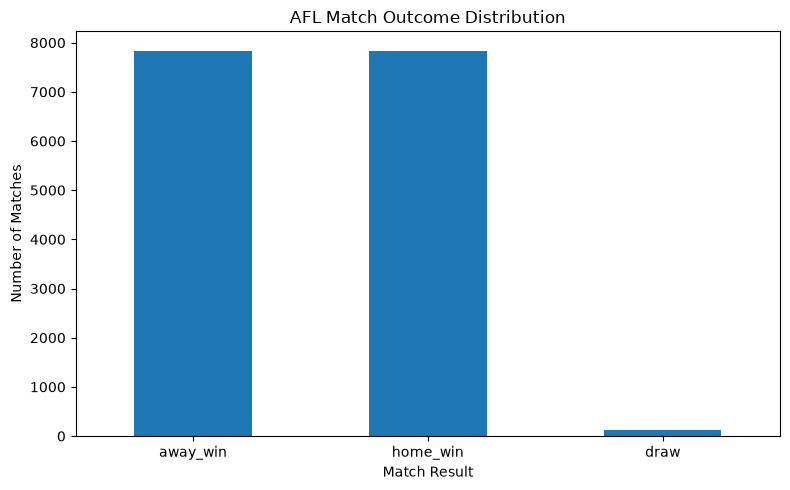

In [45]:
#  Home Advantage Visualization

plt.figure(figsize=(8, 5))

match_outcomes.plot(kind="bar")

plt.title("AFL Match Outcome Distribution")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
# Home Advantage Percentages

home_win_percentage = (
    team_matches["match_result"].eq("home_win").mean() * 100
)

away_win_percentage = (
    team_matches["match_result"].eq("away_win").mean() * 100
)

draw_percentage = (
    team_matches["match_result"].eq("draw").mean() * 100
)

print(f"Home Win Rate: {home_win_percentage:.2f}%")
print(f"Away Win Rate: {away_win_percentage:.2f}%")
print(f"Draw Rate: {draw_percentage:.2f}%")

Home Win Rate: 49.59%
Away Win Rate: 49.59%
Draw Rate: 0.82%


In [47]:
#  Season-wise Match Analysis
season_analysis = (
    team_matches
    .groupby("year")
    .agg(
        matches=("id", "count"),
        average_team_score=("team_score", "mean"),
        average_opponent_score=("opponent_score", "mean"),
        average_margin=("margin", "mean")
    )
    .round(2)
)

display(season_analysis)

,matches,average_team_score,average_opponent_score,average_margin
year,,,,
1983,276,105.88,105.88,0.00
1984,276,103.16,103.16,0.00
1985,276,105.71,105.71,0.00
1986,276,101.17,101.17,0.00
1987,320,104.21,104.21,0.00
1988,320,97.34,97.34,0.00
1989,320,95.33,95.33,0.00
1990,322,99.49,99.49,0.00
1991,344,102.40,102.40,0.00


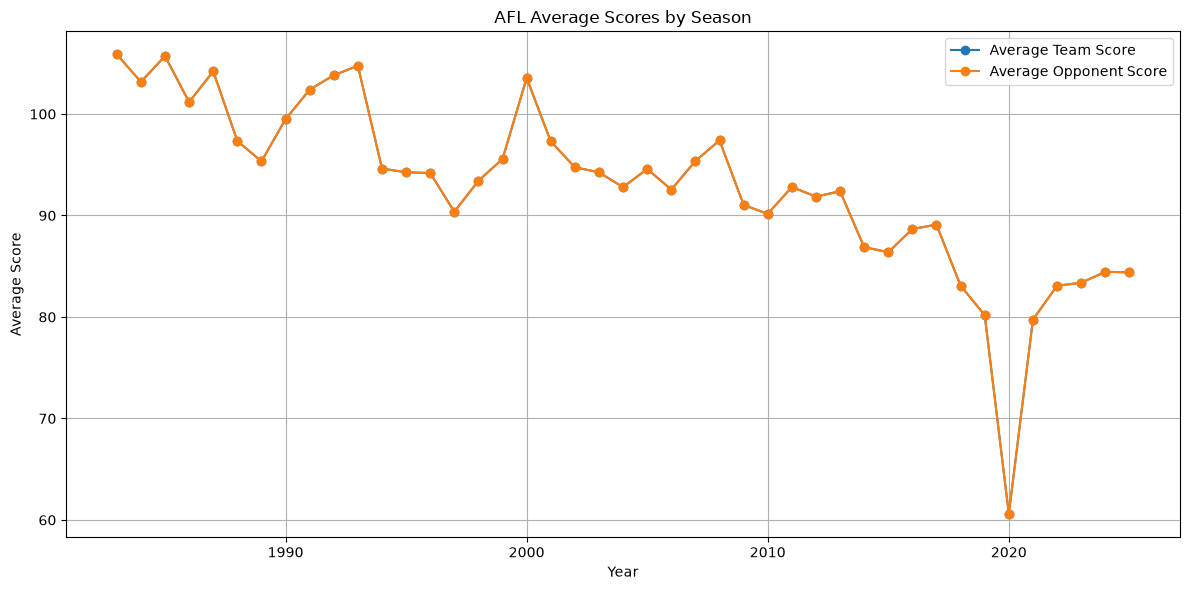

In [48]:
# Season-wise Scoring Trend
plt.figure(figsize=(12, 6))

plt.plot(
    season_analysis.index,
    season_analysis["average_team_score"],
    marker="o",
    label="Average Team Score"
)

plt.plot(
    season_analysis.index,
    season_analysis["average_opponent_score"],
    marker="o",
    label="Average Opponent Score"
)

plt.title("AFL Average Scores by Season")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

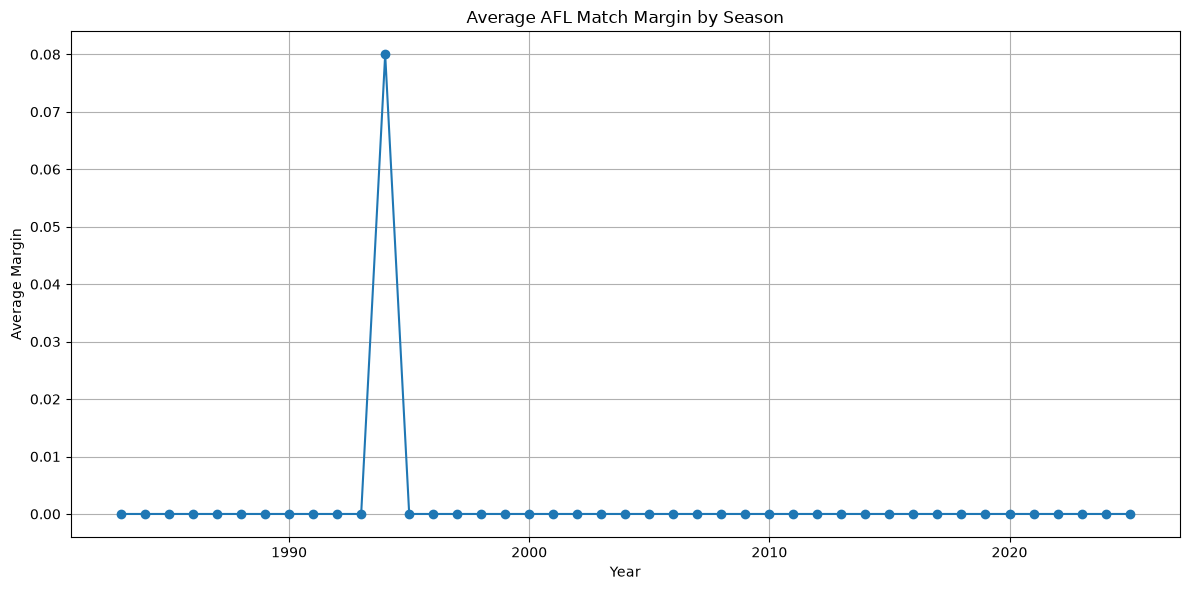

In [49]:
# Average Margin Trend

plt.figure(figsize=(12, 6))

plt.plot(
    season_analysis.index,
    season_analysis["average_margin"],
    marker="o"
)

plt.title("Average AFL Match Margin by Season")
plt.xlabel("Year")
plt.ylabel("Average Margin")
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
#  Player Performance Summary

player_performance = player_stats[
    ["disposals", "goals", "tackles", "marks", "fantasy_points"]
].describe()

display(player_performance)

,disposals,goals,tackles,marks,fantasy_points
count,265636.000000,199352.000000,245407.000000,266038.000000,274089.000000
mean,15.070299,0.825108,2.648698,4.078474,65.244187
std,7.304748,1.147711,2.050778,2.550794,28.110251
min,-5.000000,0.000000,0.000000,0.000000,-10.000000
25%,10.000000,0.000000,1.000000,2.000000,45.000000
50%,14.000000,0.000000,2.000000,4.000000,64.000000
75%,20.000000,1.000000,4.000000,6.000000,84.000000
max,54.000000,16.000000,20.000000,24.000000,210.000000


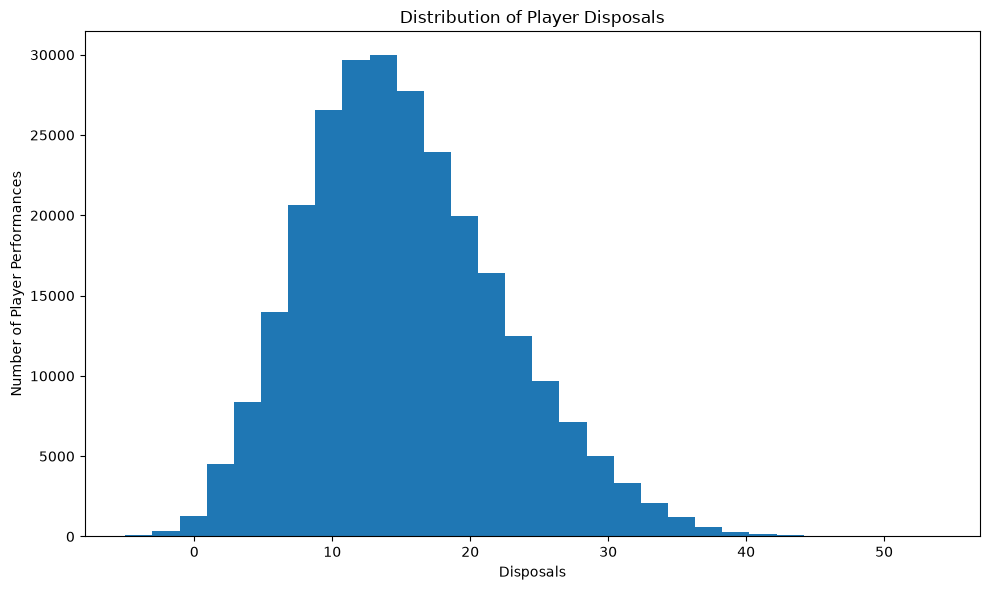

In [51]:
# Disposals Distribution

plt.figure(figsize=(10, 6))

player_stats["disposals"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Player Disposals")
plt.xlabel("Disposals")
plt.ylabel("Number of Player Performances")
plt.tight_layout()
plt.show()

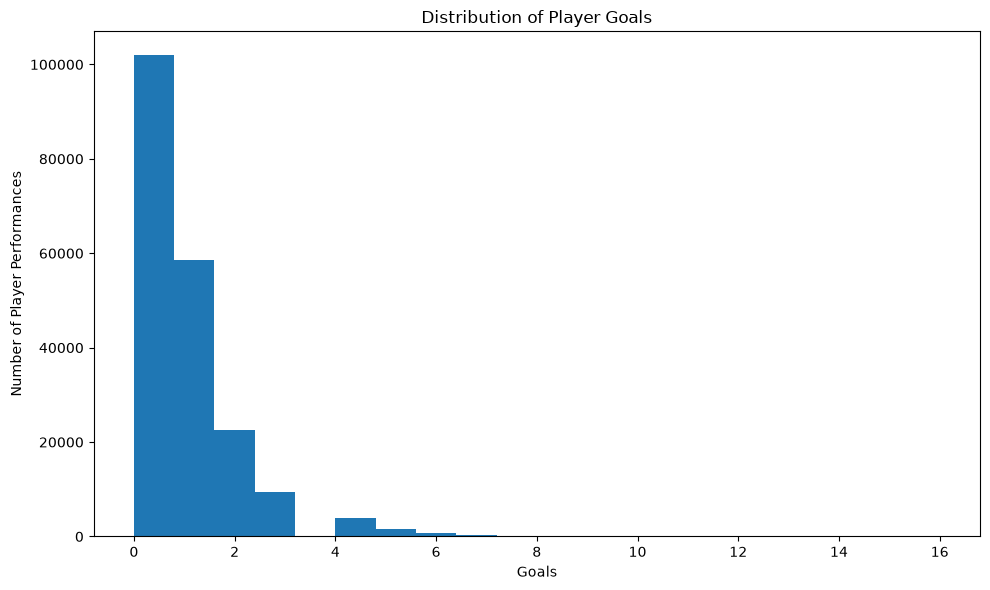

In [52]:
# Goals Distribution

plt.figure(figsize=(10, 6))

player_stats["goals"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Player Goals")
plt.xlabel("Goals")
plt.ylabel("Number of Player Performances")
plt.tight_layout()
plt.show()

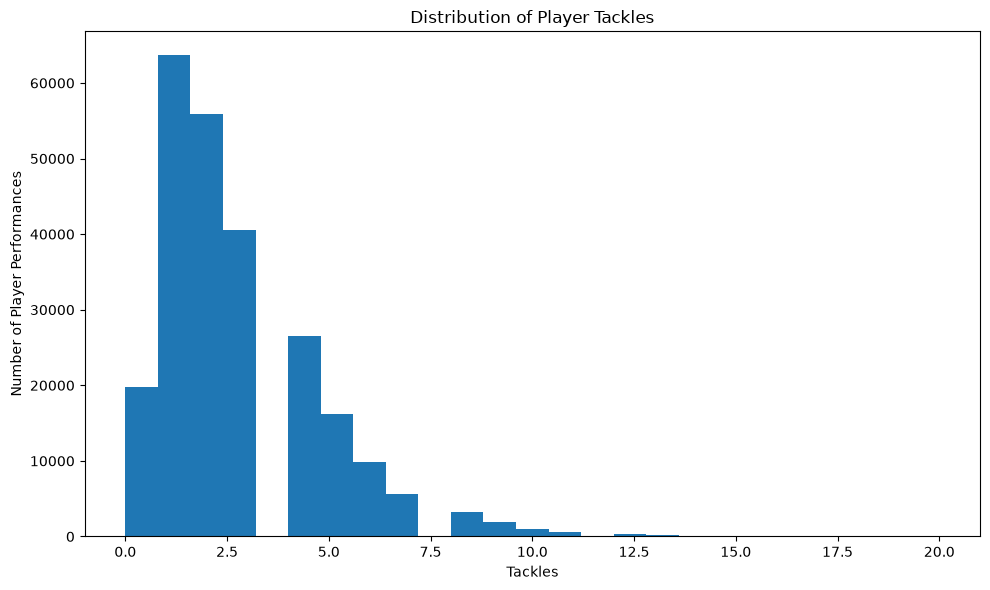

In [53]:
# Tackles Distribution

plt.figure(figsize=(10, 6))

player_stats["tackles"].plot(
    kind="hist",
    bins=25
)

plt.title("Distribution of Player Tackles")
plt.xlabel("Tackles")
plt.ylabel("Number of Player Performances")
plt.tight_layout()
plt.show()

In [54]:
#  Historical Top Disposal Leaders

top_disposal_leaders = (
    player_stats
    .groupby("player_id")
    .agg(
        total_disposals=("disposals", "sum"),
        total_matches=("id", "count"),
        total_goals=("goals", "sum")
    )
    .sort_values("total_disposals", ascending=False)
)

display(top_disposal_leaders.head(10))

,total_disposals,total_matches,total_goals
player_id,,,
44673,10502.0,425,204.0
45577,9267.0,383,215.0
45576,8815.0,432,518.0
43262,8686.0,357,445.0
43406,8620.0,387,215.0
45380,8571.0,375,247.0
44892,8489.0,355,175.0
44508,8335.0,329,71.0
45957,8016.0,324,104.0


In [55]:
# Historical Top Goal Leaders

top_goal_leaders = (
    player_stats
    .groupby("player_id")
    .agg(
        total_goals=("goals", "sum"),
        total_matches=("id", "count"),
        total_disposals=("disposals", "sum")
    )
    .sort_values("total_goals", ascending=False)
)

display(top_goal_leaders.head(10))

,total_goals,total_matches,total_disposals
player_id,,,
45679,1360.0,281,2763.0
43847,1066.0,354,5072.0
45677,926.0,270,3404.0
45833,800.0,282,3825.0
44012,796.0,359,4302.0
44785,787.0,347,2373.0
45845,748.0,257,2329.0
45563,746.0,289,3336.0
43516,736.0,280,3679.0


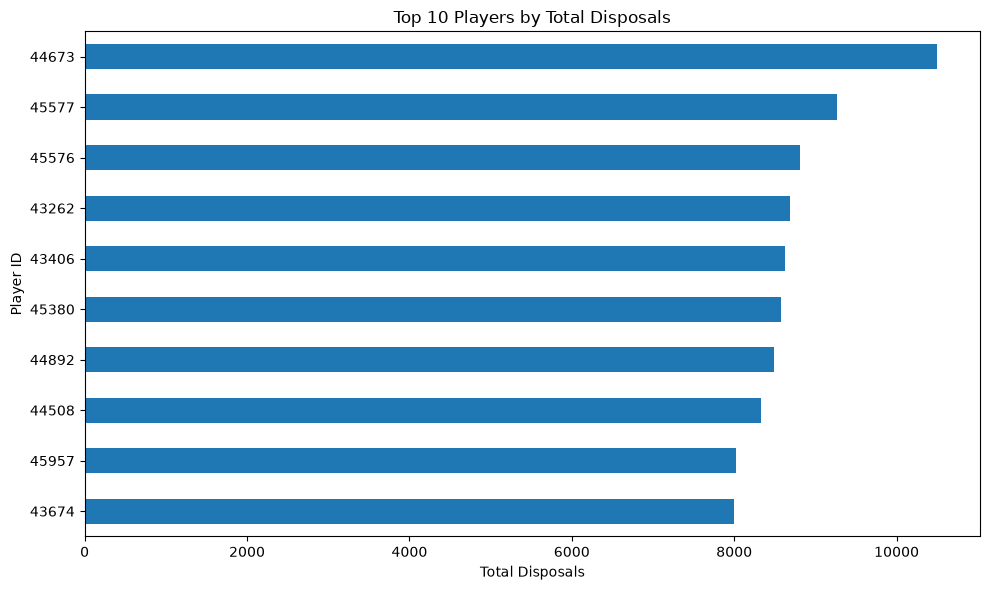

In [56]:
# Top 10 Disposal Leaders

top_10_disposals = top_disposal_leaders.head(10)

plt.figure(figsize=(10, 6))

top_10_disposals["total_disposals"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Players by Total Disposals")
plt.xlabel("Total Disposals")
plt.ylabel("Player ID")
plt.tight_layout()
plt.show()

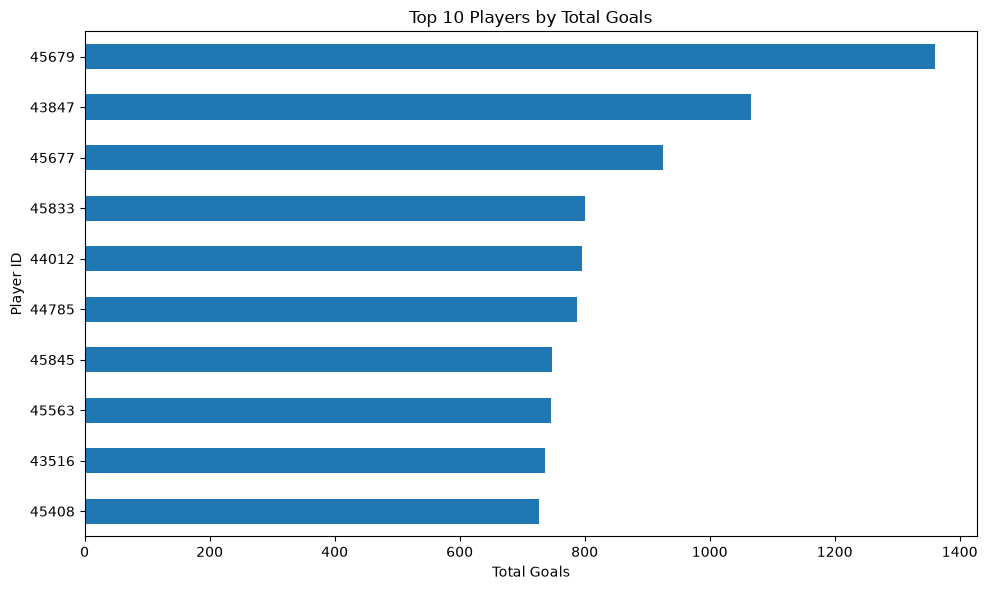

In [58]:
# Top 10 Goal Leaders

top_10_goals = top_goal_leaders.head(10)

plt.figure(figsize=(10, 6))

top_10_goals["total_goals"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Players by Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Player ID")
plt.tight_layout()
plt.show()

In [59]:
# Player Consistency Analysis

player_consistency = (
    player_stats
    .groupby("player_id")
    .agg(
        matches=("id", "count"),
        average_disposals=("disposals", "mean"),
        disposal_std=("disposals", "std"),
        average_goals=("goals", "mean"),
        goal_std=("goals", "std")
    )
)

# Only consider players with at least 10 matches
player_consistency = player_consistency[
    player_consistency["matches"] >= 10
].copy()

display(player_consistency.sort_values(
    "disposal_std",
    ascending=True
).head(10))

,matches,average_disposals,disposal_std,average_goals,goal_std
player_id,,,,,
46284,10,4.250000,1.488048,1.375000,0.744024
44861,10,3.800000,1.873796,1.100000,0.875595
45004,10,10.900000,1.911951,0.000000,0.000000
45491,14,3.384615,1.938146,1.000000,0.000000
46227,13,20.846154,2.075498,NaN,NaN
44565,13,20.818182,2.088932,0.000000,0.000000
44991,12,6.545455,2.207425,0.166667,0.389249
46266,14,5.615385,2.218801,1.250000,0.500000
43851,14,6.538462,2.221688,1.142857,1.231456


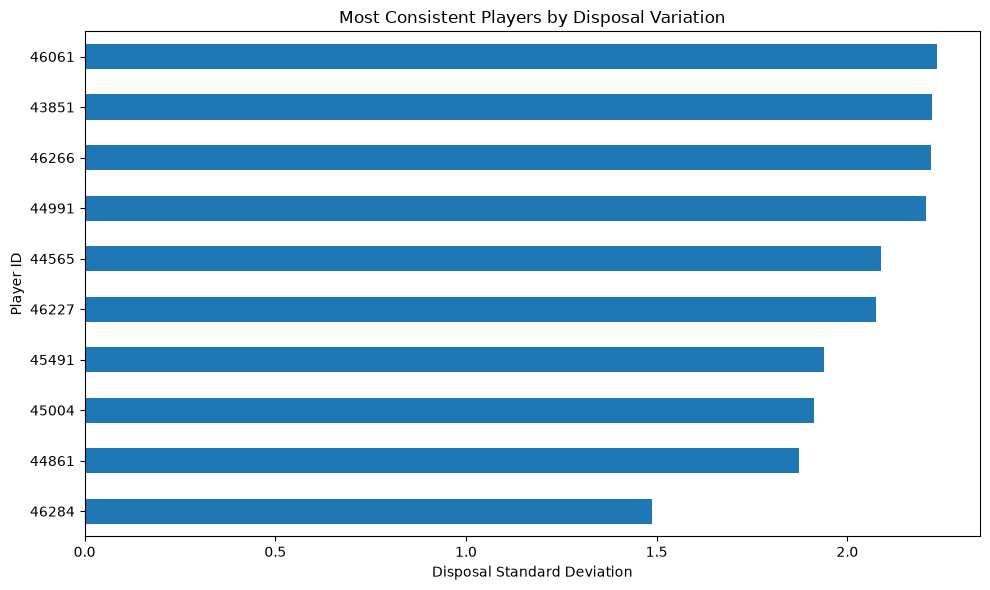

In [60]:
# Most Consistent Players

most_consistent = (
    player_consistency
    .sort_values("disposal_std")
    .head(10)
)

plt.figure(figsize=(10, 6))

most_consistent["disposal_std"].sort_values().plot(
    kind="barh"
)

plt.title("Most Consistent Players by Disposal Variation")
plt.xlabel("Disposal Standard Deviation")
plt.ylabel("Player ID")
plt.tight_layout()
plt.show()

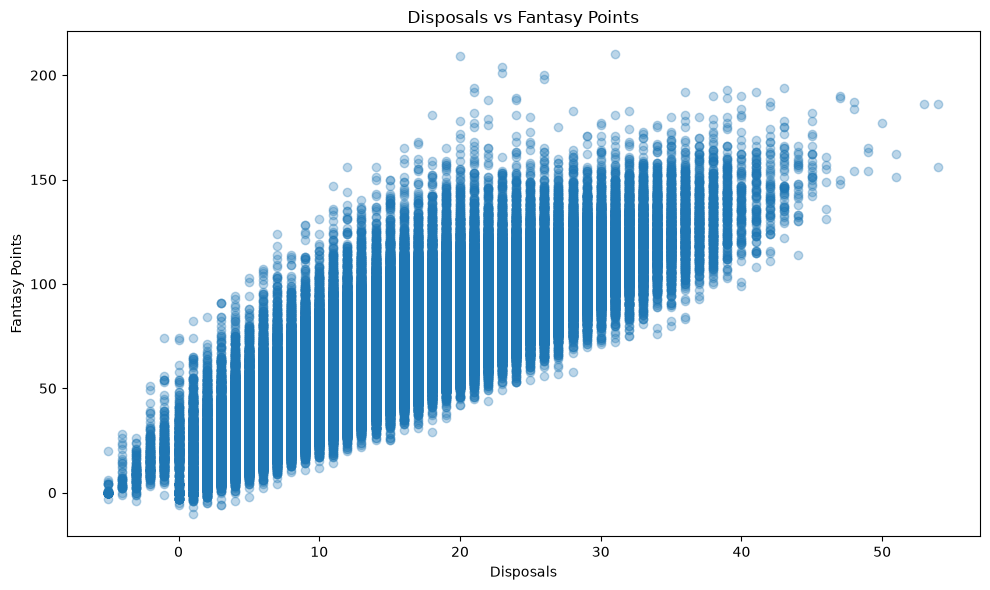

In [61]:
#  Disposals vs Fantasy Points

plt.figure(figsize=(10, 6))

plt.scatter(
    player_stats["disposals"],
    player_stats["fantasy_points"],
    alpha=0.3
)

plt.title("Disposals vs Fantasy Points")
plt.xlabel("Disposals")
plt.ylabel("Fantasy Points")
plt.tight_layout()
plt.show()

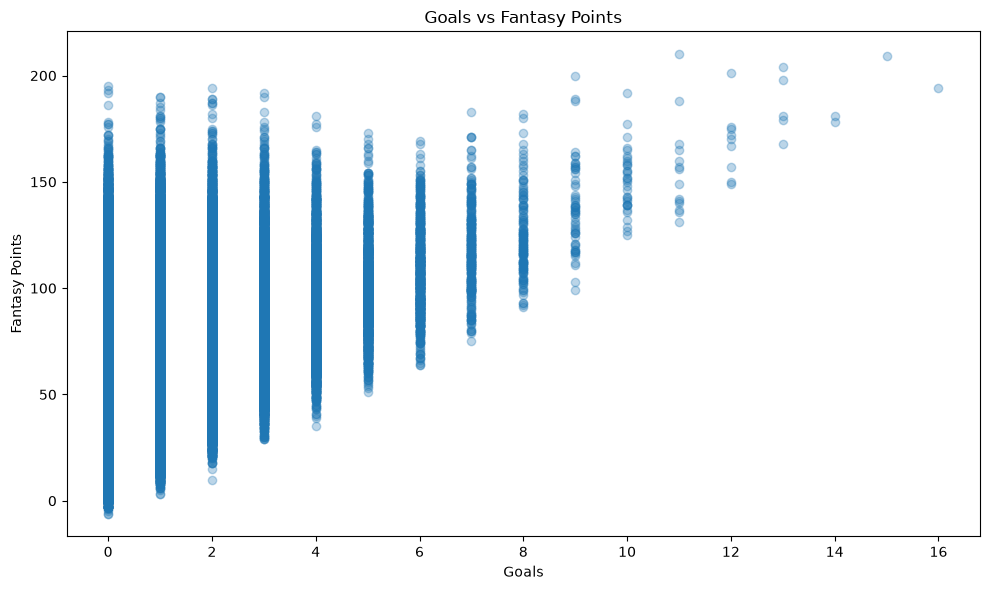

In [62]:
# Goals vs Fantasy Points

plt.figure(figsize=(10, 6))

plt.scatter(
    player_stats["goals"],
    player_stats["fantasy_points"],
    alpha=0.3
)

plt.title("Goals vs Fantasy Points")
plt.xlabel("Goals")
plt.ylabel("Fantasy Points")
plt.tight_layout()
plt.show()

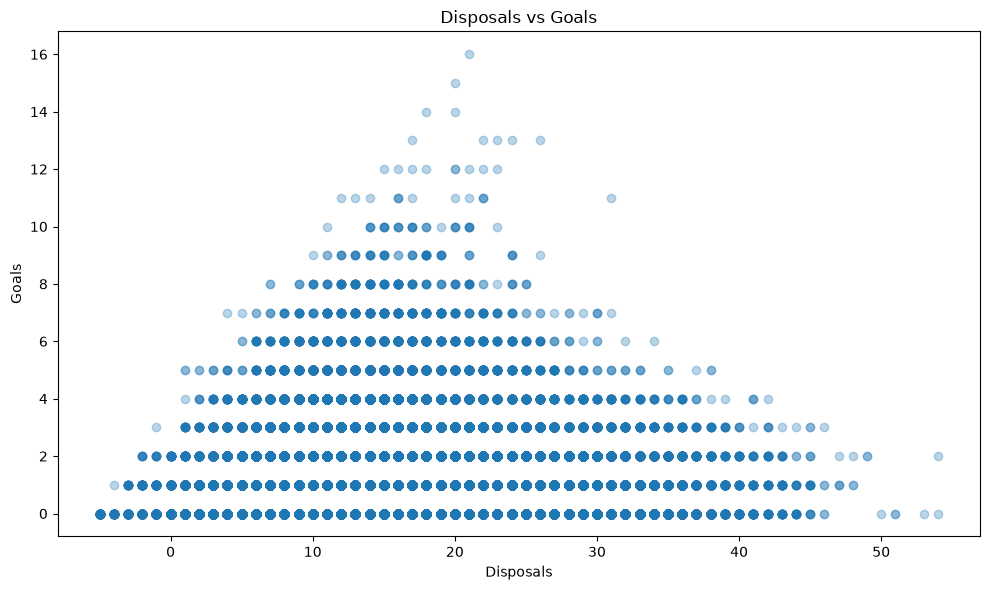

In [63]:
# Disposals vs Goals

plt.figure(figsize=(10, 6))

plt.scatter(
    player_stats["disposals"],
    player_stats["goals"],
    alpha=0.3
)

plt.title("Disposals vs Goals")
plt.xlabel("Disposals")
plt.ylabel("Goals")
plt.tight_layout()
plt.show()

In [64]:
# Correlation Analysis

performance_corr = player_stats[
    ["disposals", "goals", "tackles", "marks", "fantasy_points"]
].corr()

display(performance_corr.round(2))

,disposals,goals,tackles,marks,fantasy_points
disposals,1.00,0.02,0.26,0.42,0.85
goals,0.02,1.00,-0.03,0.21,0.32
tackles,0.26,-0.03,1.00,-0.07,0.44
marks,0.42,0.21,-0.07,1.00,0.61
fantasy_points,0.85,0.32,0.44,0.61,1.00


# Task 3 — EDA Findings and Summary

The exploratory data analysis provided several insights into AFL team and player performance.

## 1. Team Performance
Team win rates were calculated to compare the overall performance of different teams. This helps identify teams that consistently achieved better match outcomes.

## 2. Match Outcomes
The distribution of home wins, away wins, and draws was analyzed to understand the overall match outcome pattern.

## 3. Home-Ground Advantage
Home and away win percentages were compared to investigate whether playing at home provides an advantage to teams.

## 4. Season Trends
Season-wise analysis was performed to examine changes in average team scores, opponent scores, and match margins over time.

## 5. Player Performance
Player-level distributions were analyzed using disposals, goals, tackles, marks, and fantasy points. These distributions help identify common performance levels and extreme performances.

## 6. Historical Leaders
Players were ranked according to their total disposals and total goals across the available dataset to identify historical performance leaders.

## 7. Player Consistency
Player consistency was examined using the standard deviation of disposals. Players with lower variation were considered more consistent performers.

## 8. Performance Relationships
Relationships between disposals, goals, tackles, and fantasy points were examined using scatter plots and correlation analysis.

## 9. Prediction-Relevant Insights
The EDA identified several variables that may be useful for future predictive modeling, including:

- Team scoring performance
- Opponent scoring performance
- Match margin
- Home/away status
- Historical team performance
- Player disposals
- Player goals
- Player tackles
- Fantasy points
- Player consistency


# Task 4 — Feature Engineering

The objective of this task is to transform the available AFL match and player-level data into meaningful features that can be used for predictive modeling.

The feature engineering process will focus on creating:

- Team-level performance features
- Recent team form
- Scoring and defensive statistics
- Home/away indicators
- Match margin features
- Player performance aggregates
- Historical performance features

All features will be constructed carefully to avoid using future information when predicting a match.

In [67]:
#  Inspect Available Features

print("Team-level columns:")
print(team_matches.columns.tolist())

print("\nPlayer-level columns:")
print(player_stats.columns.tolist())

Team-level columns:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_result']

Player-level columns:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin', 'top_disposals', 'top_goals']


In [69]:
# Prepare Match Data

team_features = team_matches.copy()

team_features["match_date"] = pd.to_datetime(
    team_features["match_date"],
    errors="coerce"
)

team_features = team_features.sort_values(
    ["team_name", "match_date"]
).reset_index(drop=True)

print("Dataset shape:", team_features.shape)
print("\nHome/Away values:")
print(team_features["home_away"].value_counts(dropna=False))

Dataset shape: (15808, 20)

Home/Away values:
home_away
H    7904
A    7904
Name: count, dtype: int64


In [71]:
# Home/Away Indicator

home_away_clean = (
    team_features["home_away"]
    .astype(str)
    .str.strip()
    .str.lower()
)

team_features["is_home"] = home_away_clean.map({
    "home": 1,
    "h": 1,
    "away": 0,
    "a": 0
})

print("Home/Away feature created.")
print(team_features["is_home"].value_counts(dropna=False))

Home/Away feature created.
is_home
1    7904
0    7904
Name: count, dtype: int64


In [75]:
# Historical Team Performance Features
import numpy as np

team_features["previous_matches"] = (
    team_features
    .groupby("team_name")
    .cumcount()
)

team_features["previous_wins"] = (
    team_features
    .groupby("team_name")["result"]
    .transform(
        lambda x: (x == "W").shift(1).fillna(0).cumsum()
    )
)

team_features["previous_win_rate"] = (
    team_features["previous_wins"]
    .div(team_features["previous_matches"].replace(0, np.nan))
    .fillna(0)
)

display(
    team_features[
        [
            "team_name",
            "match_date",
            "previous_matches",
            "previous_wins",
            "previous_win_rate"
        ]
    ].head(10)
)

,team_name,match_date,previous_matches,previous_wins,previous_win_rate
0,\t Adelaide Crows,1991-03-22,0,0,0
1,\t Adelaide Crows,1991-09-01,1,1,1.0
2,\t Adelaide Crows,1993-04-04,2,2,1.0
3,\t Adelaide Crows,1993-04-25,3,3,1.0
4,\t Adelaide Crows,1993-05-16,4,3,0.75
5,\t Adelaide Crows,1993-05-30,5,4,0.8
6,\t Adelaide Crows,1993-07-16,6,5,0.833333
7,\t Adelaide Crows,1994-06-19,7,6,0.857143
8,\t Adelaide Crows,1995-08-19,8,7,0.875
9,\t Adelaide Crows,1996-04-06,9,7,0.777778


In [77]:
# Recent Team Form

team_features["win_numeric"] = (
    team_features["result"]
    .astype(str)
    .str.upper()
    .eq("W")
    .astype(int)
)

team_features["recent_win_rate_5"] = (
    team_features
    .groupby("team_name")["win_numeric"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

team_features["recent_win_rate_5"] = (
    team_features["recent_win_rate_5"].fillna(0)
)

display(
    team_features[
        [
            "team_name",
            "match_date",
            "win_numeric",
            "recent_win_rate_5"
        ]
    ].head(10)
)

,team_name,match_date,win_numeric,recent_win_rate_5
0,\t Adelaide Crows,1991-03-22,1,0.00
1,\t Adelaide Crows,1991-09-01,1,1.00
2,\t Adelaide Crows,1993-04-04,1,1.00
3,\t Adelaide Crows,1993-04-25,0,1.00
4,\t Adelaide Crows,1993-05-16,1,0.75
5,\t Adelaide Crows,1993-05-30,1,0.80
6,\t Adelaide Crows,1993-07-16,1,0.80
7,\t Adelaide Crows,1994-06-19,1,0.80
8,\t Adelaide Crows,1995-08-19,0,0.80
9,\t Adelaide Crows,1996-04-06,1,0.80


In [79]:
# Historical Scoring Performance

team_features["previous_avg_score"] = (
    team_features
    .groupby("team_name")["team_score"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

team_features["previous_avg_conceded"] = (
    team_features
    .groupby("team_name")["opponent_score"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

team_features["recent_avg_score_5"] = (
    team_features
    .groupby("team_name")["team_score"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

team_features["recent_avg_conceded_5"] = (
    team_features
    .groupby("team_name")["opponent_score"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

display(
    team_features[
        [
            "team_name",
            "match_date",
            "previous_avg_score",
            "previous_avg_conceded",
            "recent_avg_score_5",
            "recent_avg_conceded_5"
        ]
    ].head(10)
)

,team_name,match_date,previous_avg_score,previous_avg_conceded,recent_avg_score_5,recent_avg_conceded_5
0,\t Adelaide Crows,1991-03-22,NaN,NaN,NaN,NaN
1,\t Adelaide Crows,1991-09-01,155.000000,69.000000,155.000000,69.000000
2,\t Adelaide Crows,1993-04-04,167.500000,88.000000,167.500000,88.000000
3,\t Adelaide Crows,1993-04-25,145.333333,87.333333,145.333333,87.333333
4,\t Adelaide Crows,1993-05-16,126.000000,84.750000,126.000000,84.750000
5,\t Adelaide Crows,1993-05-30,125.400000,92.000000,125.400000,92.000000
6,\t Adelaide Crows,1993-07-16,124.833333,90.833333,118.800000,95.200000
7,\t Adelaide Crows,1994-06-19,131.428571,82.428571,117.000000,80.200000
8,\t Adelaide Crows,1995-08-19,125.375000,81.875000,113.400000,78.600000
9,\t Adelaide Crows,1996-04-06,121.777778,88.222222,118.400000,91.000000


In [81]:
# Historical Margin Features

team_features["previous_avg_margin"] = (
    team_features
    .groupby("team_name")["margin"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

team_features["recent_avg_margin_5"] = (
    team_features
    .groupby("team_name")["margin"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

display(
    team_features[
        [
            "team_name",
            "match_date",
            "previous_avg_margin",
            "recent_avg_margin_5"
        ]
    ].head(10)
)

,team_name,match_date,previous_avg_margin,recent_avg_margin_5
0,\t Adelaide Crows,1991-03-22,NaN,NaN
1,\t Adelaide Crows,1991-09-01,86.000000,86.00
2,\t Adelaide Crows,1993-04-04,79.500000,79.50
3,\t Adelaide Crows,1993-04-25,58.000000,58.00
4,\t Adelaide Crows,1993-05-16,41.250000,41.25
5,\t Adelaide Crows,1993-05-30,33.400000,33.40
6,\t Adelaide Crows,1993-07-16,34.000000,23.60
7,\t Adelaide Crows,1994-06-19,49.000000,36.80
8,\t Adelaide Crows,1995-08-19,43.500000,34.80
9,\t Adelaide Crows,1996-04-06,33.555556,27.40


In [84]:
# Opponent Historical Performance
history_lookup = team_features[
    [
        "team_name",
        "match_date",
        "previous_win_rate",
        "recent_win_rate_5",
        "previous_avg_score",
        "previous_avg_conceded",
        "recent_avg_score_5",
        "recent_avg_conceded_5",
        "previous_avg_margin",
        "recent_avg_margin_5"
    ]
].copy()

history_lookup = history_lookup.rename(columns={
    "team_name": "opponent",
    "previous_win_rate": "opponent_previous_win_rate",
    "recent_win_rate_5": "opponent_recent_win_rate_5",
    "previous_avg_score": "opponent_previous_avg_score",
    "previous_avg_conceded": "opponent_previous_avg_conceded",
    "recent_avg_score_5": "opponent_recent_avg_score_5",
    "recent_avg_conceded_5": "opponent_recent_avg_conceded_5",
    "previous_avg_margin": "opponent_previous_avg_margin",
    "recent_avg_margin_5": "opponent_recent_avg_margin_5"
})

team_features = pd.merge(
    team_features,
    history_lookup,
    on=["opponent", "match_date"],
    how="left"
)

display(
    team_features[
        [
            "team_name",
            "opponent",
            "match_date",
            "opponent_previous_win_rate",
            "opponent_recent_win_rate_5"
        ]
    ].head(10)
)

,team_name,opponent,match_date,opponent_previous_win_rate,opponent_recent_win_rate_5
0,\t Adelaide Crows,hawthorn hawks,1991-03-22,NaN,NaN
1,\t Adelaide Crows,North Melbourne Kangaroos,1991-09-01,0.489796,0.4
2,\t Adelaide Crows,West Coast Eagles,1993-04-04,0.578947,1.0
3,\t Adelaide Crows,Melbourne Demons,1993-04-25,0.472727,0.0
4,\t Adelaide Crows,North Melbourne Kangaroos,1993-05-16,NaN,NaN
5,\t Adelaide Crows,Brisbane Bears,1993-05-30,0.24812,0.4
6,\t Adelaide Crows,Richmond Tigers,1993-07-16,0.310185,0.2
7,\t Adelaide Crows,Melbourne Demons,1994-06-19,0.487805,0.2
8,\t Adelaide Crows,Sydney Swans,1995-08-19,NaN,NaN
9,\t Adelaide Crows,Fitzroy Lions,1996-04-06,0.385455,0.0


In [86]:
#  Relative Strength Features
team_features["win_rate_difference"] = (
    team_features["previous_win_rate"]
    - team_features["opponent_previous_win_rate"]
)

team_features["recent_form_difference"] = (
    team_features["recent_win_rate_5"]
    - team_features["opponent_recent_win_rate_5"]
)

team_features["scoring_strength_difference"] = (
    team_features["previous_avg_score"]
    - team_features["opponent_previous_avg_score"]
)

team_features["defensive_strength_difference"] = (
    team_features["opponent_previous_avg_conceded"]
    - team_features["previous_avg_conceded"]
)

team_features["recent_scoring_difference"] = (
    team_features["recent_avg_score_5"]
    - team_features["opponent_recent_avg_score_5"]
)

display(
    team_features[
        [
            "team_name",
            "opponent",
            "win_rate_difference",
            "recent_form_difference",
            "scoring_strength_difference",
            "defensive_strength_difference",
            "recent_scoring_difference"
        ]
    ].head(10)
)

,team_name,opponent,win_rate_difference,recent_form_difference,scoring_strength_difference,defensive_strength_difference,recent_scoring_difference
0,\t Adelaide Crows,hawthorn hawks,NaN,NaN,NaN,NaN,NaN
1,\t Adelaide Crows,North Melbourne Kangaroos,0.510204,0.6,47.250000,42.321429,52.200000
2,\t Adelaide Crows,West Coast Eagles,0.421053,0.0,65.966165,3.360902,56.300000
3,\t Adelaide Crows,Melbourne Demons,0.527273,1.0,47.674242,15.239394,43.933333
4,\t Adelaide Crows,North Melbourne Kangaroos,NaN,NaN,NaN,NaN,NaN
5,\t Adelaide Crows,Brisbane Bears,0.55188,0.4,39.287218,24.563910,11.200000
6,\t Adelaide Crows,Richmond Tigers,0.523148,0.6,28.662037,26.388889,21.800000
7,\t Adelaide Crows,Melbourne Demons,0.369338,0.6,33.115563,18.299071,32.400000
8,\t Adelaide Crows,Sydney Swans,NaN,NaN,NaN,NaN,NaN
9,\t Adelaide Crows,Fitzroy Lions,0.392323,0.8,27.035960,20.745051,49.400000


In [88]:
# Aggregate Player Performance by Team and Match

player_match_features = (
    player_stats
    .groupby(
        ["team", "match_date", "round", "opponent"],
        as_index=False
    )
    .agg(
        team_avg_disposals=("disposals", "mean"),
        team_total_disposals=("disposals", "sum"),
        team_avg_goals=("goals", "mean"),
        team_total_goals=("goals", "sum"),
        team_avg_tackles=("tackles", "mean"),
        team_avg_marks=("marks", "mean"),
        team_avg_fantasy_points=("fantasy_points", "mean"),
        team_total_fantasy_points=("fantasy_points", "sum")
    )
)

player_match_features["match_date"] = pd.to_datetime(
    player_match_features["match_date"],
    errors="coerce"
)

player_match_features = player_match_features.sort_values(
    ["team", "match_date"]
).reset_index(drop=True)

display(player_match_features.head())

,team,match_date,round,opponent,team_avg_disposals,team_total_disposals,team_avg_goals,team_total_goals,team_avg_tackles,team_avg_marks,team_avg_fantasy_points,team_total_fantasy_points
0,Adelaide Crows,1991-03-22,1,Hawthorn Hawks,8.5,17.0,NaN,0.0,1.0,6.0,34.500000,69
1,Adelaide Crows,1991-03-31,2,Carlton Blues,13.0,13.0,NaN,0.0,4.0,1.0,52.000000,52
2,Adelaide Crows,1991-04-07,3,Sydney Swans,13.0,13.0,1.0,1.0,NaN,2.0,48.000000,48
3,Adelaide Crows,1991-04-13,4,Essendon Bombers,14.5,29.0,NaN,0.0,3.0,2.0,48.500000,97
4,Adelaide Crows,1991-04-21,5,West Coast Eagles,12.5,25.0,2.0,4.0,1.0,2.0,39.333333,118


In [90]:
# Historical Player Performance

player_match_features["previous_avg_disposals"] = (
    player_match_features
    .groupby("team")["team_avg_disposals"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

player_match_features["previous_avg_goals"] = (
    player_match_features
    .groupby("team")["team_avg_goals"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

player_match_features["previous_avg_tackles"] = (
    player_match_features
    .groupby("team")["team_avg_tackles"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

player_match_features["previous_avg_fantasy_points"] = (
    player_match_features
    .groupby("team")["team_avg_fantasy_points"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

display(
    player_match_features[
        [
            "team",
            "match_date",
            "previous_avg_disposals",
            "previous_avg_goals",
            "previous_avg_tackles",
            "previous_avg_fantasy_points"
        ]
    ].head(10)
)

,team,match_date,previous_avg_disposals,previous_avg_goals,previous_avg_tackles,previous_avg_fantasy_points
0,Adelaide Crows,1991-03-22,NaN,NaN,NaN,NaN
1,Adelaide Crows,1991-03-31,8.500000,NaN,1.000000,34.500000
2,Adelaide Crows,1991-04-07,10.750000,NaN,2.500000,43.250000
3,Adelaide Crows,1991-04-13,11.500000,1.000000,2.500000,44.833333
4,Adelaide Crows,1991-04-21,12.250000,1.000000,2.666667,45.750000
5,Adelaide Crows,1991-04-28,12.300000,1.500000,2.250000,44.466667
6,Adelaide Crows,1991-05-04,12.333333,2.333333,2.200000,46.166667
7,Adelaide Crows,1991-05-17,12.380952,2.333333,2.111111,45.285714
8,Adelaide Crows,1991-05-24,12.708333,2.125000,2.023810,45.875000
9,Adelaide Crows,1991-06-01,12.907407,2.100000,2.177083,47.944444


In [92]:
#  Recent Player Performance
player_match_features["recent_avg_disposals_5"] = (
    player_match_features
    .groupby("team")["team_avg_disposals"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match_features["recent_avg_goals_5"] = (
    player_match_features
    .groupby("team")["team_avg_goals"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match_features["recent_avg_tackles_5"] = (
    player_match_features
    .groupby("team")["team_avg_tackles"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

player_match_features["recent_avg_fantasy_points_5"] = (
    player_match_features
    .groupby("team")["team_avg_fantasy_points"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

display(
    player_match_features[
        [
            "team",
            "match_date",
            "recent_avg_disposals_5",
            "recent_avg_goals_5",
            "recent_avg_tackles_5",
            "recent_avg_fantasy_points_5"
        ]
    ].head(10)
)

,team,match_date,recent_avg_disposals_5,recent_avg_goals_5,recent_avg_tackles_5,recent_avg_fantasy_points_5
0,Adelaide Crows,1991-03-22,NaN,NaN,NaN,NaN
1,Adelaide Crows,1991-03-31,8.500000,NaN,1.000000,34.500000
2,Adelaide Crows,1991-04-07,10.750000,NaN,2.500000,43.250000
3,Adelaide Crows,1991-04-13,11.500000,1.000000,2.500000,44.833333
4,Adelaide Crows,1991-04-21,12.250000,1.000000,2.666667,45.750000
5,Adelaide Crows,1991-04-28,12.300000,1.500000,2.250000,44.466667
6,Adelaide Crows,1991-05-04,13.100000,2.333333,2.500000,48.500000
7,Adelaide Crows,1991-05-17,13.033333,2.333333,1.916667,46.100000
8,Adelaide Crows,1991-05-24,13.433333,2.500000,1.833333,46.500000
9,Adelaide Crows,1991-06-01,13.433333,2.375000,1.883333,49.700000


In [93]:
#  Merge Historical Player Features

player_history = player_match_features[
    [
        "team",
        "match_date",
        "previous_avg_disposals",
        "previous_avg_goals",
        "previous_avg_tackles",
        "previous_avg_fantasy_points",
        "recent_avg_disposals_5",
        "recent_avg_goals_5",
        "recent_avg_tackles_5",
        "recent_avg_fantasy_points_5"
    ]
].copy()

player_history = player_history.rename(columns={
    "team": "team_name"
})

team_features = pd.merge(
    team_features,
    player_history,
    on=["team_name", "match_date"],
    how="left"
)

display(
    team_features[
        [
            "team_name",
            "match_date",
            "previous_avg_disposals",
            "previous_avg_goals",
            "recent_avg_disposals_5",
            "recent_avg_fantasy_points_5"
        ]
    ].head(10)
)

,team_name,match_date,previous_avg_disposals,previous_avg_goals,recent_avg_disposals_5,recent_avg_fantasy_points_5
0,\t Adelaide Crows,1991-03-22,NaN,NaN,NaN,NaN
1,\t Adelaide Crows,1991-09-01,NaN,NaN,NaN,NaN
2,\t Adelaide Crows,1993-04-04,NaN,NaN,NaN,NaN
3,\t Adelaide Crows,1993-04-25,NaN,NaN,NaN,NaN
4,\t Adelaide Crows,1993-05-16,NaN,NaN,NaN,NaN
5,\t Adelaide Crows,1993-05-30,NaN,NaN,NaN,NaN
6,\t Adelaide Crows,1993-07-16,NaN,NaN,NaN,NaN
7,\t Adelaide Crows,1994-06-19,NaN,NaN,NaN,NaN
8,\t Adelaide Crows,1995-08-19,NaN,NaN,NaN,NaN
9,\t Adelaide Crows,1996-04-06,NaN,NaN,NaN,NaN


In [95]:
# Handle Missing Values

feature_columns = [
    "previous_win_rate",
    "recent_win_rate_5",
    "previous_avg_score",
    "previous_avg_conceded",
    "recent_avg_score_5",
    "recent_avg_conceded_5",
    "previous_avg_margin",
    "recent_avg_margin_5",
    "opponent_previous_win_rate",
    "opponent_recent_win_rate_5",
    "opponent_previous_avg_score",
    "opponent_previous_avg_conceded",
    "opponent_recent_avg_score_5",
    "opponent_recent_avg_conceded_5",
    "opponent_previous_avg_margin",
    "opponent_recent_avg_margin_5",
    "win_rate_difference",
    "recent_form_difference",
    "scoring_strength_difference",
    "defensive_strength_difference",
    "recent_scoring_difference",
    "previous_avg_disposals",
    "previous_avg_goals",
    "previous_avg_tackles",
    "previous_avg_fantasy_points",
    "recent_avg_disposals_5",
    "recent_avg_goals_5",
    "recent_avg_tackles_5",
    "recent_avg_fantasy_points_5"
]

for col in feature_columns:
    if col in team_features.columns:
        team_features[col] = team_features[col].fillna(0)

print("Missing values in engineered features:")
print(team_features[feature_columns].isna().sum().sum())

Missing values in engineered features:
0


In [97]:
# Final Predictive Features

final_feature_columns = [
    "is_home",
    "previous_matches",
    "previous_win_rate",
    "recent_win_rate_5",
    "previous_avg_score",
    "previous_avg_conceded",
    "recent_avg_score_5",
    "recent_avg_conceded_5",
    "previous_avg_margin",
    "recent_avg_margin_5",
    "opponent_previous_win_rate",
    "opponent_recent_win_rate_5",
    "opponent_previous_avg_score",
    "opponent_previous_avg_conceded",
    "opponent_recent_avg_score_5",
    "opponent_recent_avg_conceded_5",
    "opponent_previous_avg_margin",
    "opponent_recent_avg_margin_5",
    "win_rate_difference",
    "recent_form_difference",
    "scoring_strength_difference",
    "defensive_strength_difference",
    "recent_scoring_difference",
    "previous_avg_disposals",
    "previous_avg_goals",
    "previous_avg_tackles",
    "previous_avg_fantasy_points",
    "recent_avg_disposals_5",
    "recent_avg_goals_5",
    "recent_avg_tackles_5",
    "recent_avg_fantasy_points_5"
]

X = team_features[final_feature_columns].copy()

y = team_features["match_result"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (15808, 31)
Target shape: (15808,)


,is_home,previous_matches,previous_win_rate,recent_win_rate_5,previous_avg_score,previous_avg_conceded,recent_avg_score_5,recent_avg_conceded_5,previous_avg_margin,recent_avg_margin_5,...,defensive_strength_difference,recent_scoring_difference,previous_avg_disposals,previous_avg_goals,previous_avg_tackles,previous_avg_fantasy_points,recent_avg_disposals_5,recent_avg_goals_5,recent_avg_tackles_5,recent_avg_fantasy_points_5
0,1,0,0,0.00,0.000000,0.000000,0.000000,0.000000,0.00,0.00,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,1.0,1.00,155.000000,69.000000,155.000000,69.000000,86.00,86.00,...,42.321429,52.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2,1.0,1.00,167.500000,88.000000,167.500000,88.000000,79.50,79.50,...,3.360902,56.300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,1.0,1.00,145.333333,87.333333,145.333333,87.333333,58.00,58.00,...,15.239394,43.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,0.75,0.75,126.000000,84.750000,126.000000,84.750000,41.25,41.25,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
# Leakage Check

leakage_columns = [
    "team_score",
    "opponent_score",
    "margin",
    "result",
    "match_result",
    "team_goals_kicked",
    "team_behinds",
    "opponent_goals_kicked",
    "opponent_behinds"
]

leakage_found = [
    col for col in leakage_columns
    if col in X.columns
]

print("Potential leakage columns found in X:")
print(leakage_found)

if len(leakage_found) == 0:
    print("\nLeakage check passed ")
else:
    print("\nWarning: leakage columns are present.")

Potential leakage columns found in X:
[]

Leakage check passed 


In [101]:
# Final Feature Summary

feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Missing Values": X.isna().sum().values
})

display(feature_summary)

print("\nTotal Features:", X.shape[1])
print("Total Samples:", X.shape[0])

,Feature,Data Type,Missing Values
0,is_home,int64,0
1,previous_matches,int64,0
2,previous_win_rate,object,0
3,recent_win_rate_5,float64,0
4,previous_avg_score,float64,0
5,previous_avg_conceded,float64,0
6,recent_avg_score_5,float64,0
7,recent_avg_conceded_5,float64,0
8,previous_avg_margin,float64,0
9,recent_avg_margin_5,float64,0



Total Features: 31
Total Samples: 15808


In [103]:
# Save Engineered Features

engineered_dataset = team_features[
    ["match_date", "team_name", "opponent", "match_result"] +
    final_feature_columns
].copy()

engineered_dataset.to_csv(
    "AFL_engineered_features.csv",
    index=False
)

print("Engineered dataset saved successfully.")
print("Shape:", engineered_dataset.shape)

Engineered dataset saved successfully.
Shape: (15808, 35)


In [105]:
#  Final Verification

print("Final Engineered Dataset")
print("=" * 40)

print("Shape:", engineered_dataset.shape)

print("\nColumns:")
print(engineered_dataset.columns.tolist())

print("\nMissing values:")
print(engineered_dataset.isna().sum().sum())

print("\nTarget distribution:")
print(engineered_dataset["match_result"].value_counts())

print("\nFirst 5 rows:")
display(engineered_dataset.head())

Final Engineered Dataset
Shape: (15808, 35)

Columns:
['match_date', 'team_name', 'opponent', 'match_result', 'is_home', 'previous_matches', 'previous_win_rate', 'recent_win_rate_5', 'previous_avg_score', 'previous_avg_conceded', 'recent_avg_score_5', 'recent_avg_conceded_5', 'previous_avg_margin', 'recent_avg_margin_5', 'opponent_previous_win_rate', 'opponent_recent_win_rate_5', 'opponent_previous_avg_score', 'opponent_previous_avg_conceded', 'opponent_recent_avg_score_5', 'opponent_recent_avg_conceded_5', 'opponent_previous_avg_margin', 'opponent_recent_avg_margin_5', 'win_rate_difference', 'recent_form_difference', 'scoring_strength_difference', 'defensive_strength_difference', 'recent_scoring_difference', 'previous_avg_disposals', 'previous_avg_goals', 'previous_avg_tackles', 'previous_avg_fantasy_points', 'recent_avg_disposals_5', 'recent_avg_goals_5', 'recent_avg_tackles_5', 'recent_avg_fantasy_points_5']

Missing values:
0

Target distribution:
match_result
home_win    7839
away

,match_date,team_name,opponent,match_result,is_home,previous_matches,previous_win_rate,recent_win_rate_5,previous_avg_score,previous_avg_conceded,...,defensive_strength_difference,recent_scoring_difference,previous_avg_disposals,previous_avg_goals,previous_avg_tackles,previous_avg_fantasy_points,recent_avg_disposals_5,recent_avg_goals_5,recent_avg_tackles_5,recent_avg_fantasy_points_5
0,1991-03-22,\t Adelaide Crows,hawthorn hawks,home_win,1,0,0,0.00,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1991-09-01,\t Adelaide Crows,North Melbourne Kangaroos,home_win,1,1,1.0,1.00,155.000000,69.000000,...,42.321429,52.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1993-04-04,\t Adelaide Crows,West Coast Eagles,home_win,1,2,1.0,1.00,167.500000,88.000000,...,3.360902,56.300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1993-04-25,\t Adelaide Crows,Melbourne Demons,away_win,0,3,1.0,1.00,145.333333,87.333333,...,15.239394,43.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1993-05-16,\t Adelaide Crows,North Melbourne Kangaroos,home_win,1,4,0.75,0.75,126.000000,84.750000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Task 4 — Feature Engineering Summary
Feature engineering was performed to transform the raw AFL match and player statistics into meaningful predictive features.
## 1. Match Context Feature
A home/away indicator was created to represent whether the team was playing at home.
## 2. Historical Team Performance
Historical win rate, average scoring, average points conceded, and average match margin were calculated using only previous matches.

## 3. Recent Team Form
Rolling five-match features were created to capture recent team performance, including:
- Recent win rate
- Recent average score
- Recent average points conceded
- Recent average margin

## 4. Opponent Strength
Historical and recent performance features were also calculated for the opponent team.

## 5. Relative Strength
Difference-based features were created to compare the team and its opponent, including:
- Win-rate difference
- Recent-form difference
- Scoring-strength difference
- Defensive-strength difference
- Recent scoring difference

## 6. Player Performance Features
Player-level statistics were aggregated at team-match level using:

- Disposals
- Goals
- Tackles
- Marks
- Fantasy points

Historical and recent player-performance averages were then created.

## 7. Missing Value Handling
Missing values occurred mainly for teams and players without previous match history. These missing historical values were handled using zero values so that the engineered dataset could be used for modeling.

## 8. Data Leakage Prevention
Current-match information such as:

- Current score
- Opponent score
- Match margin
- Current result
- Current goals
- Current behinds

was excluded from the predictive feature matrix.

Historical and rolling features were shifted by one match so that only information available before the current match was used.

## 9. Final Dataset
The final engineered dataset contains historical team performance, recent form, opponent strength, relative performance, home/away information, and historical player performance features.


# Task 5 — Predictive Modeling

The objective of this task is to build and evaluate machine learning models for predicting AFL match outcomes.

The engineered features from Task 4 will be used as input variables.

The modeling process will include:

- Preparing the feature matrix and target variable
- Encoding categorical information where required
- Splitting the data into training and testing sets
- Training baseline machine learning models
- Evaluating model performance
- Comparing different models
- Identifying the best-performing model

The evaluation will use appropriate classification metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

In [107]:
%pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.3 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 1.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 1.8 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.4 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.4 MB/s eta 0:00:04
   ------------- -----------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


Libraries imported successfully.


In [8]:
team_matches = ...
player_stats = ...

In [10]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\samir\OneDrive\Desktop\Week3\Day1
['AFL-Dataset.ipynb', 'AFL_engineered_features.csv', 'afl_players_info_raw.csv', 'afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv', 'afl_players_seasonal_stats_raw.csv', 'team_matches_home_away_raw - team_matches_home_away_raw.csv.csv']


In [11]:
import pandas as pd
import numpy as np

team_matches = pd.read_csv(
    "team_matches_home_away_raw - team_matches_home_away_raw.csv.csv"
)

player_stats = pd.read_csv(
    "afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv"
)

print("team_matches:", team_matches.shape)
print("player_stats:", player_stats.shape)

team_matches: (15808, 19)
player_stats: (274089, 36)


In [12]:
import pandas as pd
import numpy as np

engineered_data = pd.read_csv("AFL_engineered_features.csv")

print("Engineered dataset shape:", engineered_data.shape)
display(engineered_data.head())

Engineered dataset shape: (15808, 35)


,match_date,team_name,opponent,match_result,is_home,previous_matches,previous_win_rate,recent_win_rate_5,previous_avg_score,previous_avg_conceded,...,defensive_strength_difference,recent_scoring_difference,previous_avg_disposals,previous_avg_goals,previous_avg_tackles,previous_avg_fantasy_points,recent_avg_disposals_5,recent_avg_goals_5,recent_avg_tackles_5,recent_avg_fantasy_points_5
0,1991-03-22,\t Adelaide Crows,hawthorn hawks,home_win,1,0,0.00,0.00,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1991-09-01,\t Adelaide Crows,North Melbourne Kangaroos,home_win,1,1,1.00,1.00,155.000000,69.000000,...,42.321429,52.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1993-04-04,\t Adelaide Crows,West Coast Eagles,home_win,1,2,1.00,1.00,167.500000,88.000000,...,3.360902,56.300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1993-04-25,\t Adelaide Crows,Melbourne Demons,away_win,0,3,1.00,1.00,145.333333,87.333333,...,15.239394,43.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1993-05-16,\t Adelaide Crows,North Melbourne Kangaroos,home_win,1,4,0.75,0.75,126.000000,84.750000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
print(engineered_data.columns.tolist())

['match_date', 'team_name', 'opponent', 'match_result', 'is_home', 'previous_matches', 'previous_win_rate', 'recent_win_rate_5', 'previous_avg_score', 'previous_avg_conceded', 'recent_avg_score_5', 'recent_avg_conceded_5', 'previous_avg_margin', 'recent_avg_margin_5', 'opponent_previous_win_rate', 'opponent_recent_win_rate_5', 'opponent_previous_avg_score', 'opponent_previous_avg_conceded', 'opponent_recent_avg_score_5', 'opponent_recent_avg_conceded_5', 'opponent_previous_avg_margin', 'opponent_recent_avg_margin_5', 'win_rate_difference', 'recent_form_difference', 'scoring_strength_difference', 'defensive_strength_difference', 'recent_scoring_difference', 'previous_avg_disposals', 'previous_avg_goals', 'previous_avg_tackles', 'previous_avg_fantasy_points', 'recent_avg_disposals_5', 'recent_avg_goals_5', 'recent_avg_tackles_5', 'recent_avg_fantasy_points_5']


In [14]:
# Prepare Data for Modeling

team_features = engineered_data.copy()

team_features["match_date"] = pd.to_datetime(team_features["match_date"])

final_feature_columns = [
    "is_home",
    "previous_matches",
    "previous_win_rate",
    "recent_win_rate_5",
    "previous_avg_score",
    "previous_avg_conceded",
    "recent_avg_score_5",
    "recent_avg_conceded_5",
    "previous_avg_margin",
    "recent_avg_margin_5",
    "opponent_previous_win_rate",
    "opponent_recent_win_rate_5",
    "opponent_previous_avg_score",
    "opponent_previous_avg_conceded",
    "opponent_recent_avg_score_5",
    "opponent_recent_avg_conceded_5",
    "opponent_previous_avg_margin",
    "opponent_recent_avg_margin_5",
    "win_rate_difference",
    "recent_form_difference",
    "scoring_strength_difference",
    "defensive_strength_difference",
    "recent_scoring_difference",
    "previous_avg_disposals",
    "previous_avg_goals",
    "previous_avg_tackles",
    "previous_avg_fantasy_points",
    "recent_avg_disposals_5",
    "recent_avg_goals_5",
    "recent_avg_tackles_5",
    "recent_avg_fantasy_points_5"
]

X = team_features[final_feature_columns].copy()
y = team_features["match_result"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (15808, 31)
y shape: (15808,)

Target distribution:
match_result
home_win    7839
away_win    7839
draw         130
Name: count, dtype: int64


In [16]:
# Encode Match Result
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    y.astype(str)
)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))

Classes: ['away_win' 'draw' 'home_win']
Encoded classes: [0 1 2]


In [17]:
#  Chronological Train/Test Split
model_data = team_features.copy()

model_data = model_data.sort_values(
    "match_date"
).reset_index(drop=True)

X_model = model_data[final_feature_columns].copy()

y_model = label_encoder.transform(
    model_data["match_result"].astype(str)
)

split_index = int(len(model_data) * 0.80)

X_train = X_model.iloc[:split_index].copy()
X_test = X_model.iloc[split_index:].copy()

y_train = y_model[:split_index]
y_test = y_model[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining date range:")
print(model_data["match_date"].iloc[:split_index].min())
print(model_data["match_date"].iloc[:split_index].max())

print("\nTesting date range:")
print(model_data["match_date"].iloc[split_index:].min())
print(model_data["match_date"].iloc[split_index:].max())

Training samples: 12646
Testing samples: 3162

Training date range:
1983-03-26 00:00:00
2018-05-05 00:00:00

Testing date range:
2018-05-05 00:00:00
2025-09-27 00:00:00


In [20]:
#  Train Predictive Models
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# Train models
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [21]:
#  Model Evaluation

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    }

In [22]:
# Compare Model Performance
results = []

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for model_name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)

    results.append({
        "Model": model_name,
        **metrics
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.627135,0.622626,0.627135,0.624574
1,Decision Tree,0.584440,0.580392,0.584440,0.581624
2,Random Forest,0.623340,0.618708,0.623340,0.620925


In [24]:
#  Classification Reports
for model_name, model in models.items():
    predictions = model.predict(X_test)

    print("-" * 70)
    print(model_name)
    print("-" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

----------------------------------------------------------------------
Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

    away_win       0.62      0.65      0.64      1568
        draw       0.00      0.00      0.00        24
    home_win       0.63      0.61      0.62      1570

    accuracy                           0.63      3162
   macro avg       0.42      0.42      0.42      3162
weighted avg       0.62      0.63      0.62      3162

----------------------------------------------------------------------
Decision Tree
----------------------------------------------------------------------
              precision    recall  f1-score   support

    away_win       0.59      0.55      0.57      1568
        draw       0.00      0.00      0.00        24
    home_win       0.58      0.63      0.60      1570

    accuracy                           0.58      3162
   macro avg       0.39      

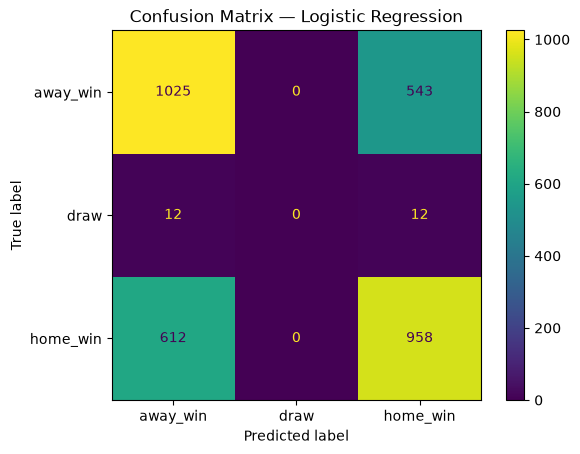

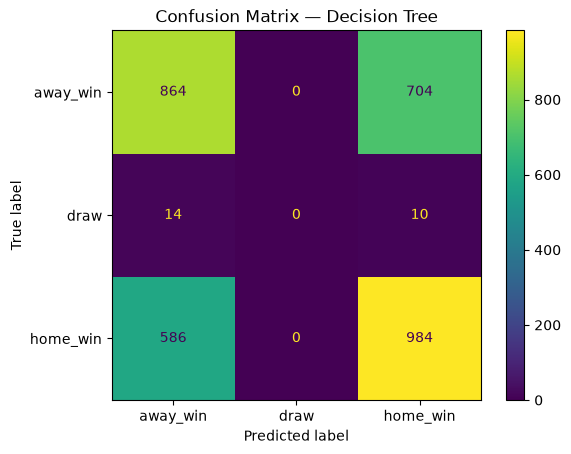

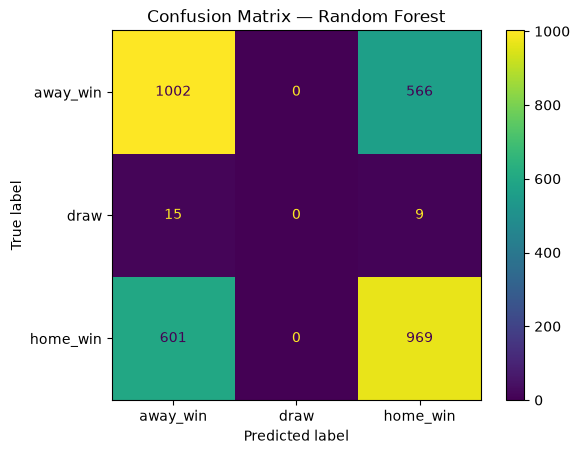

In [26]:
#  Confusion Matrices
for model_name, model in models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot()
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

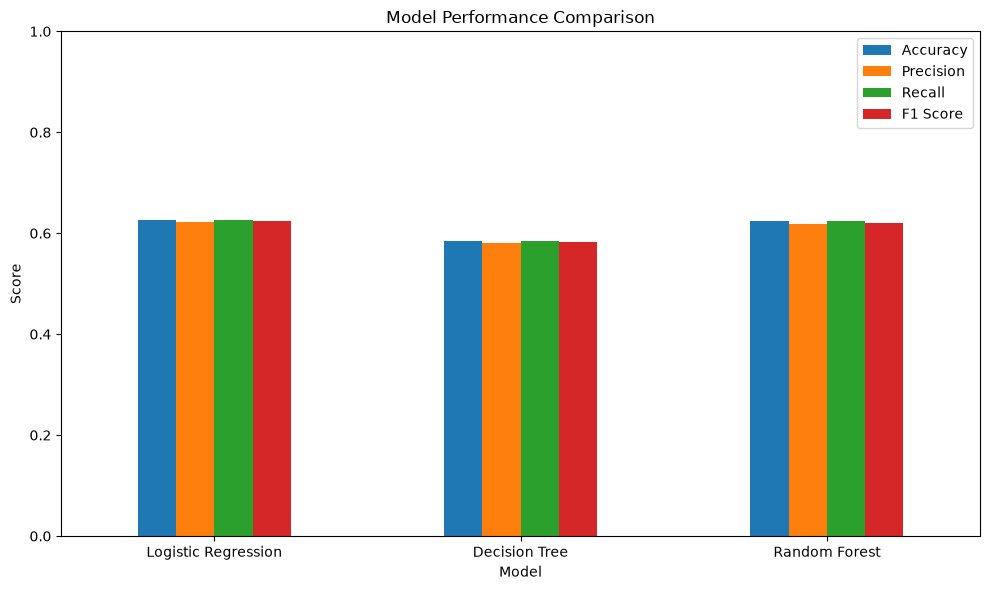

In [ ]:
# Model Performance Comparison

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Select Best Model

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)
print(
    "Best F1 Score:",
    results_df["F1 Score"].max()
)

Best Model: Logistic Regression
Best F1 Score: 0.624574244926634


In [29]:
#  Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": final_feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
0,is_home,0.103477
9,recent_avg_margin_5,0.070724
17,opponent_recent_avg_margin_5,0.056708
22,recent_scoring_difference,0.049785
19,recent_form_difference,0.047623
7,recent_avg_conceded_5,0.046168
15,opponent_recent_avg_conceded_5,0.039124
5,previous_avg_conceded,0.032215
6,recent_avg_score_5,0.032022
21,defensive_strength_difference,0.031402


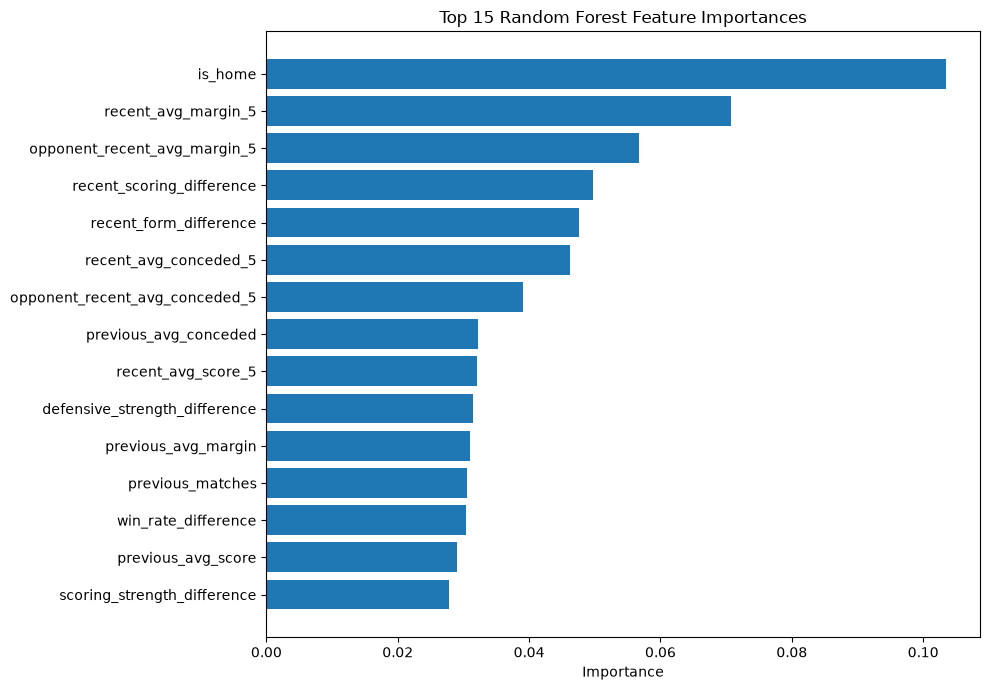

In [30]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [32]:
# Save Models and Results
import joblib

joblib.dump(
    logistic_model,
    "AFL_logistic_model.joblib"
)

joblib.dump(
    decision_tree_model,
    "AFL_decision_tree_model.joblib"
)

joblib.dump(
    random_forest_model,
    "AFL_random_forest_model.joblib"
)

results_df.to_csv(
    "AFL_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "AFL_feature_importance.csv",
    index=False
)


# Task 5 — Predictive Modeling

Three machine learning models were developed to predict AFL match outcomes:

1. Logistic Regression
2. Decision Tree
3. Random Forest

A chronological 80/20 train-test split was used so that earlier matches were used for training and later matches were used for testing. This approach better represents a real-world sports prediction scenario and reduces the risk of using future information during training.

The target variable `match_result` was encoded using LabelEncoder into three classes:

- away_win
- draw
- home_win

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

The three models were compared using their evaluation metrics, and the model with the highest F1 Score was selected as the best-performing model.

Random Forest feature importance was also analyzed to identify the most influential engineered features for match-result prediction.
